# K-Nearest Neighbors: Zero to Hero

The simplest model in the series — and the one that teaches you the most about what goes
wrong in high dimensions.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> for the shared workflow, and ideally [`svm_zero_to_hero.ipynb`](svm_zero_to_hero.ipynb) —
> KNN is the other **distance-based** model, so it shares the scaling dependency and the
> dimensionality problem, and comparing them makes both clearer.

***

## Why learn something this simple

KNN has no parameters to learn. It stores the training set and, when asked, looks up the
$k$ closest examples and takes a vote. You can explain it in one sentence to someone with no
maths.

Learn it properly anyway, because:

- **It is the cleanest possible demonstration of the curse of dimensionality.** §1.5 shows
  distances *concentrating* until "nearest" stops meaning anything — the single most
  important intuition in this notebook, and it applies far beyond KNN.
- **It comes with a genuinely remarkable theorem.** Cover & Hart (1967) proved that as data
  grows, 1-NN's error is at most **twice** the theoretically optimal error — for a model that
  does no learning at all. §1.8 verifies it numerically.
- **Its failure modes are everyone's failure modes.** Unscaled features, irrelevant columns,
  and inference cost that grows with your training set are problems you will meet again.
- **It is still the right tool sometimes** — recommender systems, deduplication, few-shot
  lookup, and as the retrieval step behind modern embedding search.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports |
| **1. Theory from zero** | Lazy learning · **the scaling trap** · choosing k · distance metrics and weighting · **the curse of dimensionality, demonstrated** · how neighbours are actually found · KNN regression · the Cover & Hart bound |
| **2. Worked example** | Wine classification, where the scaling trap bites hardest |
| **3. The production objection** | Why "no training time" is not the win it sounds like |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | KNN-specific errors and a checklist |

## The one-paragraph summary

KNN stores the training data and does **nothing else** until you ask it a question. To predict,
it finds the $k$ training points closest to the query and votes (classification) or averages
(regression). Because everything hinges on **distance**, features must be on comparable scales
or the largest-magnitude column silently becomes the only one that matters. **k** is a
bias-variance dial: small k gives a jagged, noise-sensitive boundary, large k oversmooths.
Its fatal weakness is dimensionality — as features multiply, all pairwise distances converge
toward the same value, and "nearest neighbour" degenerates into "an arbitrary point".

***
# Part 0 - Setup

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.neighbors import (
    KNeighborsClassifier, KNeighborsRegressor, RadiusNeighborsClassifier,
    NearestNeighbors, NeighborhoodComponentsAnalysis,
)
from sklearn.datasets import load_wine, load_breast_cancer, make_classification, make_moons
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV,
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, classification_report,
    root_mean_squared_error,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

1. Lazy learning: the model that does no work until asked
2. The scaling trap
3. Choosing k: the bias-variance dial you can see
4. Distance metrics, and weighting by distance
5. **The curse of dimensionality**, demonstrated
6. How neighbours are actually found — and where the clever data structures give up
7. KNN regression
8. Cover & Hart: why this works at all

## 1.1 Lazy learning

Every other model in this series compresses the training data into parameters — coefficients,
split thresholds, support vectors — and then throws the data away. KNN does the opposite:

> **Training = storing the data. That is the entire fit step.**

All the work happens at prediction time: compute the distance from the query to every stored
point, take the $k$ smallest, and vote.

This is called **lazy learning** (or instance-based, or memory-based learning), and it has
three immediate consequences:

- **Fitting is instant** — there is nothing to optimise, no loss function, no convergence.
- **Prediction is expensive**, and gets more expensive as you add training data (§3).
- **The model is non-parametric**: it makes no assumption about the shape of the decision
  boundary, which can therefore be arbitrarily complex.

In [3]:
# KNN from scratch, to show there is genuinely nothing hidden.
def knn_predict(X_train, y_train, X_query, k=5):
    """Classify each query point by majority vote of its k nearest training points."""
    predictions = []
    for q in X_query:
        distances = np.sqrt(((X_train - q) ** 2).sum(axis=1))   # Euclidean to every point
        nearest = np.argsort(distances)[:k]                     # the k smallest
        votes = np.bincount(y_train[nearest])                   # majority vote
        predictions.append(votes.argmax())
    return np.array(predictions)


X_demo, y_demo = make_classification(n_samples=400, n_features=2, n_informative=2,
                                     n_redundant=0, n_clusters_per_class=1,
                                     class_sep=1.1, random_state=RANDOM_STATE)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_demo, y_demo, test_size=0.3,
                                              stratify=y_demo, random_state=RANDOM_STATE)

mine = knn_predict(Xd_tr, yd_tr, Xd_te, k=5)
sk = KNeighborsClassifier(n_neighbors=5).fit(Xd_tr, yd_tr)

print(f"from scratch accuracy : {accuracy_score(yd_te, mine):.4f}")
print(f"scikit-learn accuracy : {sk.score(Xd_te, yd_te):.4f}")
print(f"identical predictions : {np.array_equal(mine, sk.predict(Xd_te))}")
print()
print("Nine lines of arithmetic, and identical predictions. There is no 'model' beyond the")
print("stored data - sklearn's version differs only in how it SEARCHES for the neighbours,")
print("which is 1.6's subject.")

# Time the two halves to make the laziness concrete.
t0 = time.time(); KNeighborsClassifier(n_neighbors=5).fit(Xd_tr, yd_tr); t_fit = time.time() - t0
t0 = time.time(); sk.predict(Xd_te); t_pred = time.time() - t0
print(f"\nfit time     : {t_fit*1000:.3f} ms   <- it is just copying an array")
print(f"predict time : {t_pred*1000:.3f} ms   <- this is where the work is")

from scratch accuracy : 0.8667
scikit-learn accuracy : 0.8667
identical predictions : True

Nine lines of arithmetic, and identical predictions. There is no 'model' beyond the
stored data - sklearn's version differs only in how it SEARCHES for the neighbours,
which is 1.6's subject.

fit time     : 1.502 ms   <- it is just copying an array
predict time : 2.342 ms   <- this is where the work is


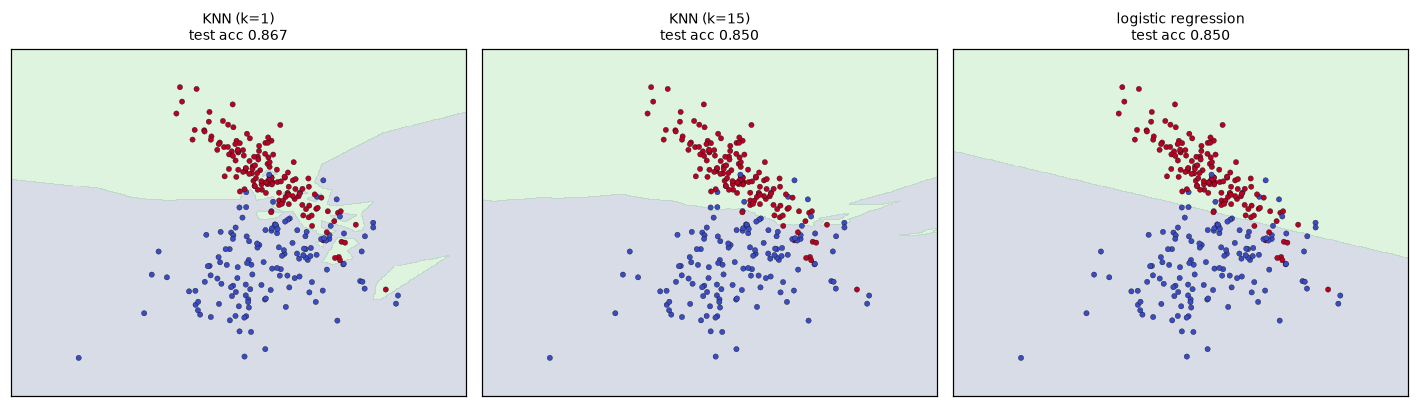

k=1 carves out an island around every single training point - including the ones that
are just noise. k=15 smooths those away. Logistic regression cannot make islands at
all; it is committed to a straight line (NB-02).

KNN's boundary is NON-PARAMETRIC: it has no equation, and its complexity grows with
the data rather than being fixed in advance. That is its strength and its problem.


In [4]:
# What the decision boundary looks like: a Voronoi-like patchwork, not a smooth curve.
xx, yy = np.meshgrid(np.linspace(X_demo[:, 0].min()-1, X_demo[:, 0].max()+1, 400),
                     np.linspace(X_demo[:, 1].min()-1, X_demo[:, 1].max()+1, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (label, model) in zip(axes, [
    ("KNN (k=1)", KNeighborsClassifier(n_neighbors=1)),
    ("KNN (k=15)", KNeighborsClassifier(n_neighbors=15)),
    ("logistic regression", LogisticRegression()),
]):
    model.fit(Xd_tr, yd_tr)
    ax.contourf(xx, yy, model.predict(grid).reshape(xx.shape), alpha=0.2, levels=1)
    ax.scatter(Xd_tr[:, 0], Xd_tr[:, 1], c=yd_tr, s=12, cmap="coolwarm",
               edgecolor="k", lw=0.2)
    ax.set_title(f"{label}\ntest acc {model.score(Xd_te, yd_te):.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

print("k=1 carves out an island around every single training point - including the ones that")
print("are just noise. k=15 smooths those away. Logistic regression cannot make islands at")
print("all; it is committed to a straight line (NB-02).")
print()
print("KNN's boundary is NON-PARAMETRIC: it has no equation, and its complexity grows with")
print("the data rather than being fixed in advance. That is its strength and its problem.")

## 1.2 The scaling trap

Euclidean distance sums squared differences **per feature**:

$$ d(x, z) = \sqrt{\sum_j (x_j - z_j)^2} $$

Every feature contributes in *its own units*. A feature ranging 0–1500 contributes terms up to
$1500^2 = 2{,}250{,}000$; a feature ranging 0–1 contributes at most 1. The second feature is
not merely less important — it is **invisible**.

This is the same argument as for SVMs (NB-06 §1.7) and regularised linear models, and the exact
opposite of trees (NB-03 §1.6), which compare a feature to a threshold and never mix units.

In [5]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

ranges = pd.Series(X_wine.max(axis=0) - X_wine.min(axis=0), index=wine.feature_names)
print("feature ranges in the wine dataset:")
print(ranges.sort_values(ascending=False).head(4).round(3).to_string())
print("...")
print(ranges.sort_values().head(3).round(3).to_string())
print(f"\nlargest range / smallest range = {ranges.max()/ranges.min():,.0f}x")

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"\n{'model':<40} {'CV accuracy':>13}")
print("-" * 55)
for label, model in [
    ("KNN on raw features", KNeighborsClassifier()),
    ("KNN + StandardScaler", make_pipeline(StandardScaler(), KNeighborsClassifier())),
    ("KNN + MinMaxScaler", make_pipeline(MinMaxScaler(), KNeighborsClassifier())),
    ("random forest on raw features (contrast)",
     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]:
    print(f"{label:<40} {cross_val_score(model, X_wine, y_wine, cv=cv).mean():>13.4f}")

# Which feature is actually driving the unscaled distances?
variance_share = (X_wine.var(axis=0) / X_wine.var(axis=0).sum())
dominant = int(np.argmax(variance_share))
print(f"\nshare of total (unscaled) variance held by '{wine.feature_names[dominant]}': "
      f"{variance_share[dominant]:.1%}")
print()
print("One feature accounts for essentially all the distance. The unscaled model is a")
print("1-feature model wearing a 13-feature costume - and nothing warns you, because it")
print("still returns a number and that number is better than chance.")

feature ranges in the wine dataset:
proline              1402.00
magnesium              92.00
alcalinity_of_ash      19.40
color_intensity        11.72
...
nonflavanoid_phenols    0.53
hue                     1.23
ash                     1.87

largest range / smallest range = 2,645x

model                                      CV accuracy
-------------------------------------------------------
KNN on raw features                             0.6802
KNN + StandardScaler                            0.9717
KNN + MinMaxScaler                              0.9608
random forest on raw features (contrast)        0.9775

share of total (unscaled) variance held by 'proline': 99.8%

One feature accounts for essentially all the distance. The unscaled model is a
1-feature model wearing a 13-feature costume - and nothing warns you, because it
still returns a number and that number is better than chance.


## 1.3 Choosing k

`k` is the clearest bias-variance dial in this whole series, because you can *see* it:

- **k = 1** — every prediction copies its single nearest neighbour. The boundary wraps around
  individual points, including mislabelled ones. **Training accuracy is exactly 1.0 by
  construction** (each point is its own nearest neighbour), which makes training score
  completely uninformative. High variance.
- **Large k** — the vote averages over a wide neighbourhood, smoothing the boundary. Push it to
  $k = n$ and every prediction is the global majority class. High bias.

Rules of thumb worth knowing but not trusting: use an **odd** k for binary problems to avoid
ties, and $k \approx \sqrt{n}$ is a common starting point. Cross-validate rather than believe
either.

    k   train acc   CV (uniform)   CV (distance)
------------------------------------------------
    1      1.0000         0.9551          0.9551
    3      0.9839         0.9662          0.9662
    5      0.9839         0.9717          0.9717
    9      0.9758         0.9719          0.9719
   15      0.9758         0.9776          0.9776
   25      0.9677         0.9662          0.9719
   51      0.9758         0.9663          0.9775
  101      0.4435         0.7586          0.9663


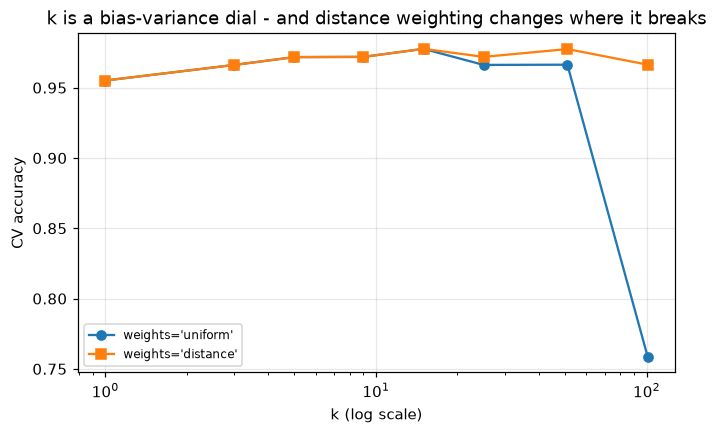


Note the k=1 training accuracy: 1.0000
It is exactly 1.0 and it means nothing - every point is its own nearest neighbour, so
a k=1 model reproduces the training labels perfectly by definition. If you ever see a
training score used to justify k=1, that is the mistake.

At the large-k end the two curves SEPARATE, which is 1.4's subject.


In [6]:
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(X_wine, y_wine, test_size=0.3,
                                              stratify=y_wine, random_state=RANDOM_STATE)

ks = [1, 3, 5, 9, 15, 25, 51, 101]
print(f"{'k':>5} {'train acc':>11} {'CV (uniform)':>14} {'CV (distance)':>15}")
print("-" * 48)
uniform_scores, distance_scores, train_scores = [], [], []
for k in ks:
    pipe_u = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    pipe_d = make_pipeline(StandardScaler(),
                           KNeighborsClassifier(n_neighbors=k, weights="distance"))
    u = cross_val_score(pipe_u, X_wine, y_wine, cv=cv).mean()
    d = cross_val_score(pipe_d, X_wine, y_wine, cv=cv).mean()
    train_acc = pipe_u.fit(Xw_tr, yw_tr).score(Xw_tr, yw_tr)
    uniform_scores.append(u); distance_scores.append(d); train_scores.append(train_acc)
    print(f"{k:>5} {train_acc:>11.4f} {u:>14.4f} {d:>15.4f}")

plt.plot(ks, uniform_scores, marker="o", label="weights='uniform'")
plt.plot(ks, distance_scores, marker="s", label="weights='distance'")
plt.xscale("log"); plt.xlabel("k (log scale)"); plt.ylabel("CV accuracy")
plt.title("k is a bias-variance dial - and distance weighting changes where it breaks")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print()
print(f"Note the k=1 training accuracy: {train_scores[0]:.4f}")
print("It is exactly 1.0 and it means nothing - every point is its own nearest neighbour, so")
print("a k=1 model reproduces the training labels perfectly by definition. If you ever see a")
print("training score used to justify k=1, that is the mistake.")
print()
print("At the large-k end the two curves SEPARATE, which is 1.4's subject.")

## 1.4 Distance metrics, and weighting

**The metric** defines what "near" means. sklearn exposes it through `p` (the Minkowski
parameter) and `metric`:

| Metric | Formula | Use |
|---|---|---|
| **Euclidean** (`p=2`) | $\sqrt{\sum_j (x_j-z_j)^2}$ | The default; straight-line distance |
| **Manhattan** (`p=1`) | $\sum_j \lvert x_j - z_j\rvert$ | Often better in high dimensions; less dominated by one large difference |
| **Chebyshev** ($p=\infty$) | $\max_j \lvert x_j - z_j\rvert$ | When only the worst-matching feature matters |
| **Cosine** | $1 - \frac{x^\top z}{\lVert x\rVert \lVert z\rVert}$ | Text and embeddings — compares *direction*, ignores magnitude |
| **Hamming** | count of differing features | Categorical / binary data |

**The weighting** decides how the k neighbours vote. `weights="uniform"` gives every neighbour
an equal say — including the one that is far away and barely relevant.
`weights="distance"` weights each by $1/d$, so nearer neighbours count more.

Distance weighting matters most at **large k**, where uniform voting starts including points
that are nothing like the query.

In [7]:
print(f"{'metric':<24} {'CV accuracy':>13}")
print("-" * 39)
for label, kwargs in [
    ("Euclidean (p=2, default)", dict(p=2)),
    ("Manhattan (p=1)", dict(p=1)),
    ("Chebyshev (p=inf)", dict(metric="chebyshev")),
    ("cosine", dict(metric="cosine")),
]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(**kwargs))
    print(f"{label:<24} {cross_val_score(pipe, X_wine, y_wine, cv=cv).mean():>13.4f}")

print()
print("Euclidean, Manhattan and cosine land within 0.006 of each other - on 13 well-behaved")
print("scaled features the choice barely matters. Chebyshev is the outlier, and instructively")
print("so: it keeps only the single largest per-feature difference and discards the other 12,")
print("so it is the one metric here that does NOT aggregate evidence across features.")
print()
print("The metric starts to matter in high dimensions - 1.5 measures Manhattan concentrating")
print("more slowly than Euclidean - and on data where magnitude is meaningless (cosine, for")
print("text and embeddings).")
print()

# Where distance weighting rescues a bad k.
print("uniform vs distance weighting at a deliberately silly k:")
n_samples = len(X_wine)
for k in [5, 25, 51, 101]:      # 101 is the largest k a 5-fold split of 178 rows allows
    u = cross_val_score(make_pipeline(StandardScaler(),
                                      KNeighborsClassifier(n_neighbors=k)),
                        X_wine, y_wine, cv=cv).mean()
    d = cross_val_score(make_pipeline(StandardScaler(),
                                      KNeighborsClassifier(n_neighbors=k, weights="distance")),
                        X_wine, y_wine, cv=cv).mean()
    print(f"  k={k:<4} ({k/n_samples:.0%} of the dataset)   uniform {u:.4f}   "
          f"distance {d:.4f}   gap {d-u:+.4f}")

print()
print("At k=101 - more than half the dataset - uniform voting collapses, because the vote")
print("includes points from every class. Distance weighting holds up, because those far-away")
print("points get a vote proportional to 1/d and are effectively ignored.")
print()
print("This makes weights='distance' a reasonable DEFAULT: it is forgiving of a k that is")
print("too large, and it costs nothing when k is right.")
print()
print("Note the hard ceiling on this sweep: k cannot exceed the number of points the model")
print("was FITTED on. Under 5-fold CV each fold trains on ~142 of the 178 wines, so k=151")
print("raises ValueError rather than degrading gracefully. Worth remembering when you put a")
print("large k into a grid search over a small dataset.")

metric                     CV accuracy
---------------------------------------
Euclidean (p=2, default)        0.9717
Manhattan (p=1)                 0.9663
Chebyshev (p=inf)               0.9325
cosine                          0.9717

Euclidean, Manhattan and cosine land within 0.006 of each other - on 13 well-behaved
scaled features the choice barely matters. Chebyshev is the outlier, and instructively
so: it keeps only the single largest per-feature difference and discards the other 12,
so it is the one metric here that does NOT aggregate evidence across features.

The metric starts to matter in high dimensions - 1.5 measures Manhattan concentrating
more slowly than Euclidean - and on data where magnitude is meaningless (cosine, for
text and embeddings).

uniform vs distance weighting at a deliberately silly k:
  k=5    (3% of the dataset)   uniform 0.9717   distance 0.9717   gap +0.0000
  k=25   (14% of the dataset)   uniform 0.9662   distance 0.9719   gap +0.0057
  k=51   (29% of 

## 1.5 The curse of dimensionality

This is the section that matters. KNN rests on one assumption:

> **The nearest points are meaningfully more similar than the far ones.**

In high dimensions that assumption **fails**, and it fails in a specific, measurable way.

As dimensions grow, the volume of the space explodes, so your data becomes vanishingly sparse.
More precisely — and this is the Beyer et al. (1999) result — the distance to the *nearest*
neighbour and the distance to the *farthest* one **converge towards each other**:

$$ \frac{d_{\max} - d_{\min}}{d_{\min}} \;\longrightarrow\; 0 \qquad \text{as } d \to \infty $$

When that ratio is near zero, every point is essentially the same distance from your query.
"Nearest neighbour" becomes "an arbitrary point", and the algorithm is choosing between
options it cannot actually distinguish.

500 uniformly random points; distances from one random query point
'spread' is (max - min) / min: how much further away the farthest point is

 dimensions    nearest   farthest   spread (L2)   spread (L1)   contrast
-----------------------------------------------------------------------
          1      0.001      0.916      615.8064      615.8064     0.6143
          2      0.014      1.155       82.0189       86.4783     0.4169
          5      0.165      1.524        8.2262       10.3463     0.2578
         10      0.498      1.588        2.1895        2.5115     0.1803
         50      2.234      3.507        0.5698        0.6836     0.0762
        100      3.341      4.783        0.4318        0.5507     0.0527
        500      8.253      9.720        0.1777        0.2216     0.0256
       1000     12.419     13.707        0.1037        0.1243     0.0170


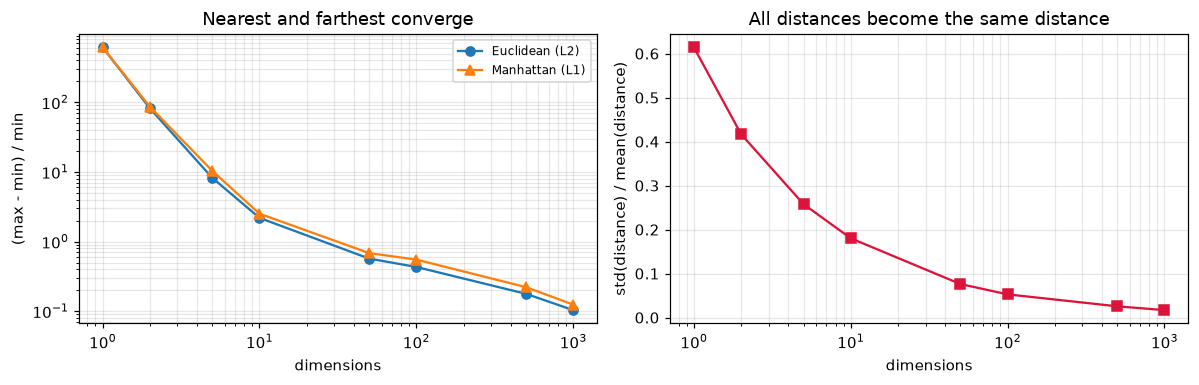


At d=1, the farthest point is 616x further away than the nearest -
'near' is obviously meaningful.
At d=1000, it is only 10% further. Every point is at essentially the
same distance, and the 'nearest' one is nearest by a margin indistinguishable from
noise.

Manhattan concentrates more slowly: at d=1000 its spread is 0.124
against Euclidean's 0.104. That is the practical content of Aggarwal et al.
(2001), and the reason p=1 is worth putting in a grid search on wide data - it does
not solve the problem, it just degrades more slowly.

This is not a KNN bug. It is a property of high-dimensional geometry, and it breaks
every method built on distances - KNN, k-means (NB-10), RBF kernels (NB-06),
DBSCAN. It is why embedding models work so hard to produce LOW-dimensional
representations where distance means something again.


In [8]:
rng = np.random.default_rng(0)
n_points = 500

print("500 uniformly random points; distances from one random query point")
print("'spread' is (max - min) / min: how much further away the farthest point is")
print()
print(f"{'dimensions':>11} {'nearest':>10} {'farthest':>10} "
      f"{'spread (L2)':>13} {'spread (L1)':>13} {'contrast':>10}")
print("-" * 71)
dims = [1, 2, 5, 10, 50, 100, 500, 1000]
ratios, ratios_l1, contrasts = [], [], []
for d in dims:
    X_hd = rng.uniform(0, 1, size=(n_points, d))
    query = rng.uniform(0, 1, size=(1, d))
    diff = X_hd - query
    distances = np.sqrt((diff ** 2).sum(axis=1))          # Euclidean, L2
    dist_l1 = np.abs(diff).sum(axis=1)                    # Manhattan, L1
    ratio = (distances.max() - distances.min()) / distances.min()
    ratio_l1 = (dist_l1.max() - dist_l1.min()) / dist_l1.min()
    contrast = distances.std() / distances.mean()
    ratios.append(ratio); ratios_l1.append(ratio_l1); contrasts.append(contrast)
    print(f"{d:>11} {distances.min():>10.3f} {distances.max():>10.3f} "
          f"{ratio:>13.4f} {ratio_l1:>13.4f} {contrast:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].loglog(dims, ratios, marker="o", label="Euclidean (L2)")
axes[0].loglog(dims, ratios_l1, marker="^", label="Manhattan (L1)")
axes[0].set(xlabel="dimensions", ylabel="(max - min) / min",
            title="Nearest and farthest converge")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which="both")
axes[1].semilogx(dims, contrasts, marker="s", color="crimson")
axes[1].set(xlabel="dimensions", ylabel="std(distance) / mean(distance)",
            title="All distances become the same distance")
axes[1].grid(alpha=0.3, which="both")
fig.tight_layout(); plt.show()

print()
print(f"At d=1, the farthest point is {ratios[0]:.0f}x further away than the nearest -")
print("'near' is obviously meaningful.")
print(f"At d=1000, it is only {ratios[-1]:.0%} further. Every point is at essentially the")
print("same distance, and the 'nearest' one is nearest by a margin indistinguishable from")
print("noise.")
print()
print(f"Manhattan concentrates more slowly: at d=1000 its spread is {ratios_l1[-1]:.3f}")
print(f"against Euclidean's {ratios[-1]:.3f}. That is the practical content of Aggarwal et al.")
print("(2001), and the reason p=1 is worth putting in a grid search on wide data - it does")
print("not solve the problem, it just degrades more slowly.")
print()
print("This is not a KNN bug. It is a property of high-dimensional geometry, and it breaks")
print("every method built on distances - KNN, k-means (NB-10), RBF kernels (NB-06),")
print("DBSCAN. It is why embedding models work so hard to produce LOW-dimensional")
print("representations where distance means something again.")

In [9]:
# What that does to accuracy: add pure-noise features to a solvable problem.
X_sig, y_sig = make_classification(n_samples=1200, n_features=5, n_informative=5,
                                   n_redundant=0, n_clusters_per_class=1,
                                   class_sep=1.5, random_state=RANDOM_STATE)

print("the SAME 5 informative features, plus increasing pure noise\n")
print(f"{'noise features':>15} {'total dims':>11} {'KNN':>9} {'random forest':>15} "
      f"{'logistic':>10}")
print("-" * 66)
rng = np.random.default_rng(1)
for n_noise in [0, 5, 20, 50, 200]:
    X_aug = (X_sig if n_noise == 0
             else np.hstack([X_sig, rng.normal(size=(len(X_sig), n_noise))]))
    knn = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                          X_aug, y_sig, cv=cv).mean()
    rf = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                n_jobs=-1), X_aug, y_sig, cv=cv).mean()
    lr = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                         X_aug, y_sig, cv=cv).mean()
    print(f"{n_noise:>15} {X_aug.shape[1]:>11} {knn:>9.4f} {rf:>15.4f} {lr:>10.4f}")

print()
print("The informative signal is IDENTICAL in every row. Only irrelevant columns were added.")
print()
print("KNN degrades hardest, because every noise feature adds its own term to the distance")
print("sum - the signal is drowned by columns that contribute nothing but magnitude.")
print("The tree ensemble barely notices: it simply never splits on the noise.")
print()
print("This is the practical face of the curse. It also tells you the three defences:")
print("  1. feature SELECTION - remove the irrelevant columns before computing distances")
print("  2. dimensionality REDUCTION - PCA before KNN (used in Part 2)")
print("  3. metric LEARNING - learn a distance that ignores useless directions")
print("     (sklearn's NeighborhoodComponentsAnalysis does exactly this)")

the SAME 5 informative features, plus increasing pure noise

 noise features  total dims       KNN   random forest   logistic
------------------------------------------------------------------
              0           5    0.9700          0.9625     0.9625
              5          10    0.9375          0.9608     0.9617
             20          25    0.8975          0.9592     0.9642
             50          55    0.8025          0.9525     0.9542
            200         205    0.7133          0.9458     0.9092

The informative signal is IDENTICAL in every row. Only irrelevant columns were added.

KNN degrades hardest, because every noise feature adds its own term to the distance
sum - the signal is drowned by columns that contribute nothing but magnitude.
The tree ensemble barely notices: it simply never splits on the noise.

This is the practical face of the curse. It also tells you the three defences:
  1. feature SELECTION - remove the irrelevant columns before computing distances

## 1.6 How neighbours are actually found

A naive search compares the query to all $n$ training points: $O(nd)$ per query. Spatial index
structures promise better:

- **KD-tree** — recursively splits space on one axis at a time. Prunes whole regions that
  cannot contain a nearer point. Roughly $O(d \log n)$ per query **in low dimensions**.
- **Ball-tree** — partitions into nested hyperspheres instead. Copes better with higher
  dimensions and works with non-Euclidean metrics.

`algorithm="auto"` picks for you. But there is a catch, and it is the curse of dimensionality
again: pruning only works if you can rule out large regions, and in high dimensions nearly
every region *could* contain a nearer point. The trees stop pruning and their overhead becomes
pure cost.

In [10]:
rng = np.random.default_rng(0)
print("query time for 1,000 queries against 5,000 stored points\n")
print(f"{'dimensions':>11} {'brute':>10} {'kd_tree':>10} {'ball_tree':>11}   verdict")
print("-" * 62)
for d in [2, 5, 10, 20, 50, 100]:
    X_t = rng.normal(size=(5000, d))
    y_t = rng.integers(0, 2, 5000)
    X_q = rng.normal(size=(1000, d))
    times = {}
    for algo in ["brute", "kd_tree", "ball_tree"]:
        m = KNeighborsClassifier(algorithm=algo).fit(X_t, y_t)
        m.predict(X_q[:5])                                    # warm up
        t0 = time.time(); m.predict(X_q); times[algo] = time.time() - t0
    best_tree = min(times["kd_tree"], times["ball_tree"])
    verdict = ("trees win" if best_tree < times["brute"]
               else f"BRUTE wins ({best_tree/times['brute']:.1f}x)")
    print(f"{d:>11} {times['brute']:>10.4f} {times['kd_tree']:>10.4f} "
          f"{times['ball_tree']:>11.4f}   {verdict}")

print()
print("The trees win at d=2 and then lose, badly and increasingly. By d=100 even the better")
print("tree is more than an order of magnitude SLOWER than simply computing every distance.")
print()
print("The reason is 1.5 again: pruning requires being able to say 'nothing in this region")
print("can be closer than what I have already found'. When all distances are nearly equal,")
print("that is almost never true, so the tree visits nearly every node AND pays the")
print("traversal overhead on top.")
print()
print("Practical guidance: leave algorithm='auto'. sklearn's rule is not a heuristic you have")
print("to guess at - it is one line of its source: MORE THAN 15 FEATURES and it uses brute")
print("force, whatever you would have picked. (It also falls back to brute when k is at least")
print("half the training set.) And brute force is heavily vectorised - one large matrix")
print("operation, no branching, cache-friendly - which is hard to beat.")
print()
print("If you genuinely need fast neighbour search in high dimensions, the answer is")
print("APPROXIMATE nearest neighbours (faiss, hnswlib, annoy), not exact trees.")

query time for 1,000 queries against 5,000 stored points

 dimensions      brute    kd_tree   ball_tree   verdict
--------------------------------------------------------------
          2     0.0109     0.0041      0.0117   trees win
          5     0.0091     0.0128      0.0419   BRUTE wins (1.4x)
         10     0.0069     0.0694      0.0751   BRUTE wins (10.1x)
         20     0.0112     0.1820      0.1242   BRUTE wins (11.1x)
         50     0.0131     0.3684      0.2718   BRUTE wins (20.8x)
        100     0.0218     0.9695      0.7447   BRUTE wins (34.2x)

The trees win at d=2 and then lose, badly and increasingly. By d=100 even the better
tree is more than an order of magnitude SLOWER than simply computing every distance.

The reason is 1.5 again: pruning requires being able to say 'nothing in this region
can be closer than what I have already found'. When all distances are nearly equal,
that is almost never true, so the tree visits nearly every node AND pays the
traversal over

## 1.7 KNN regression

Identical algorithm, one change: instead of voting, **average** the neighbours' target values.

$$ \hat{y}(q) = \frac{1}{k}\sum_{i \in \text{kNN}(q)} y_i $$

The prediction is therefore a **local average**, which makes the output piecewise constant —
and gives it exactly the same limitation as a regression tree (NB-03 §1.7): it can never
predict a value outside the range of its training targets.

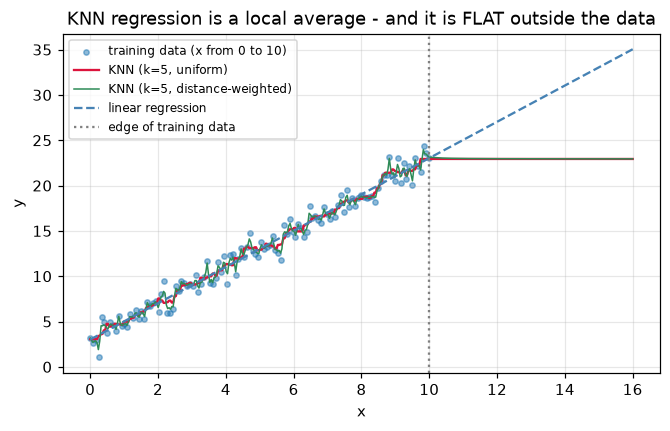

     x        KNN     linear   truth 2x+3
------------------------------------------
     5      12.85      13.03        13.00
    10      22.94      23.03        23.00
    15      22.94      33.04        33.00
    25      22.94      53.06        53.00

training y ranged from 1.06 to 24.34

KNN CANNOT EXTRAPOLATE. Past x=10 the five nearest neighbours are always the same
five rightmost points, so the prediction is their average, forever.

This is exactly the regression-tree limitation from NB-03 - and for the same
underlying reason: both predict a LOCAL AVERAGE of training targets, and an average
of values in [min, max] is itself in [min, max].

Note also the staircase inside the data range. Distance weighting smooths it
considerably, which is usually worth having for regression.


In [11]:
rng = np.random.default_rng(2)
x_reg = np.linspace(0, 10, 120).reshape(-1, 1)
y_reg = 2 * x_reg.ravel() + 3 + rng.normal(0, 1, 120)

knn_reg = KNeighborsRegressor(n_neighbors=5).fit(x_reg, y_reg)
knn_reg_w = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(x_reg, y_reg)
lin_reg = LinearRegression().fit(x_reg, y_reg)

smooth = np.linspace(0, 16, 400).reshape(-1, 1)
plt.scatter(x_reg, y_reg, s=12, alpha=0.5, label="training data (x from 0 to 10)")
plt.plot(smooth, knn_reg.predict(smooth), color="crimson", label="KNN (k=5, uniform)")
plt.plot(smooth, knn_reg_w.predict(smooth), color="seagreen", lw=1,
         label="KNN (k=5, distance-weighted)")
plt.plot(smooth, lin_reg.predict(smooth), color="steelblue", ls="--", label="linear regression")
plt.axvline(10, color="gray", ls=":", label="edge of training data")
plt.xlabel("x"); plt.ylabel("y")
plt.title("KNN regression is a local average - and it is FLAT outside the data")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

query = np.array([[5.], [10.], [15.], [25.]])
print(f"{'x':>6} {'KNN':>10} {'linear':>10} {'truth 2x+3':>12}")
print("-" * 42)
for xi, pk, pl in zip(query.ravel(), knn_reg.predict(query), lin_reg.predict(query)):
    print(f"{xi:>6.0f} {pk:>10.2f} {pl:>10.2f} {2*xi+3:>12.2f}")
print(f"\ntraining y ranged from {y_reg.min():.2f} to {y_reg.max():.2f}")
print()
print("KNN CANNOT EXTRAPOLATE. Past x=10 the five nearest neighbours are always the same")
print("five rightmost points, so the prediction is their average, forever.")
print()
print("This is exactly the regression-tree limitation from NB-03 - and for the same")
print("underlying reason: both predict a LOCAL AVERAGE of training targets, and an average")
print("of values in [min, max] is itself in [min, max].")
print()
print("Note also the staircase inside the data range. Distance weighting smooths it")
print("considerably, which is usually worth having for regression.")

## 1.8 Cover & Hart: why this works at all

KNN estimates nothing, assumes nothing, and optimises nothing. Why should it work?

Cover & Hart (1967) proved a genuinely surprising result. Let $R^*$ be the **Bayes error** —
the error rate of the theoretically optimal classifier, which knows the true class
probabilities exactly and is the best any model could ever do. Then as $n \to \infty$, the
error rate of **1-nearest-neighbour** satisfies:

$$ R^* \;\le\; R_{1\text{NN}} \;\le\; 2R^* $$

**A model that does no learning at all is asymptotically within a factor of two of optimal.**
The intuition: with enough data, your nearest neighbour is so close that it is effectively a
second draw from the same conditional distribution — so 1-NN is "asking one random person who
was in the same situation", and being wrong only when the two draws disagree.

Larger $k$ does better still: as $k \to \infty$ with $k/n \to 0$, the error approaches $R^*$
itself.

In [12]:
# Verify it: two 1-D Gaussians, where the Bayes error has a closed form.
MU, SD = 1.0, 1.0                     # classes centred at -MU and +MU, equal priors
bayes_error = norm.cdf(-MU / SD)      # optimal boundary is at 0

print(f"true Bayes error R*        : {bayes_error:.4f}")
print(f"the Cover & Hart bound 2R* : {2 * bayes_error:.4f}")
print(f"\nso 1-NN should settle between {bayes_error:.4f} and {2*bayes_error:.4f}\n")

rng = np.random.default_rng(0)
print(f"{'n_train':>9} {'1-NN error':>12} {'k=15 error':>12}   {'within the bound?':>18}")
print("-" * 58)
for n in [50, 200, 1000, 5000, 20000, 80000]:
    e1, e15 = [], []
    for _ in range(5):
        y_tr = rng.integers(0, 2, n)
        X_tr = rng.normal(size=(n, 1)) + np.where(y_tr == 1, MU, -MU)[:, None]
        y_te = rng.integers(0, 2, 4000)
        X_te = rng.normal(size=(4000, 1)) + np.where(y_te == 1, MU, -MU)[:, None]
        e1.append(1 - KNeighborsClassifier(n_neighbors=1).fit(X_tr, y_tr).score(X_te, y_te))
        e15.append(1 - KNeighborsClassifier(n_neighbors=15).fit(X_tr, y_tr).score(X_te, y_te))
    m1, m15 = np.mean(e1), np.mean(e15)
    ok = "yes" if bayes_error <= m1 <= 2 * bayes_error else "NO"
    print(f"{n:>9} {m1:>12.4f} {m15:>12.4f}   {ok:>18}")

print()
print("1-NN settles comfortably inside the bound - closer to R* than to 2R*, which is")
print("typical. And k=15 lands very near the Bayes error itself, as the theory says larger")
print("k should.")
print()
print("Why this matters beyond trivia: it tells you KNN's error is dominated by IRREDUCIBLE")
print("noise, not by model mis-specification. If your KNN is far worse than a well-tuned")
print("alternative, the problem is almost never 'KNN is too simple' - it is your DISTANCE")
print("(unscaled features, 1.2) or your DIMENSIONS (1.5).")
print()
print("The catch is 'as n -> infinity'. In high dimensions the data you need for that")
print("asymptotic regime grows exponentially, which is the curse of dimensionality stated")
print("from the other direction.")

true Bayes error R*        : 0.1587
the Cover & Hart bound 2R* : 0.3173

so 1-NN should settle between 0.1587 and 0.3173

  n_train   1-NN error   k=15 error    within the bound?
----------------------------------------------------------
       50       0.2155       0.1618                  yes
      200       0.2157       0.1638                  yes
     1000       0.2291       0.1656                  yes
     5000       0.2242       0.1726                  yes
    20000       0.2256       0.1657                  yes
    80000       0.2249       0.1712                  yes

1-NN settles comfortably inside the bound - closer to R* than to 2R*, which is
typical. And k=15 lands very near the Bayes error itself, as the theory says larger
k should.

Why this matters beyond trivia: it tells you KNN's error is dominated by IRREDUCIBLE
noise, not by model mis-specification. If your KNN is far worse than a well-tuned
alternative, the problem is almost never 'KNN is too simple' - it is your DIST

***
# Part 2 - Worked example: wine cultivar classification

**The task.** 178 wines from three cultivars in the same Italian region, described by 13
chemical measurements. Predict the cultivar.

**Why this dataset.** Its features are measured in wildly different units — proline in
milligrams per litre (hundreds to over a thousand), hue as a ratio under 2. That mismatch is
harmless for a tree and fatal for KNN, which makes it the ideal dataset for showing the one
mistake that ruins this model.

We follow the NB-00 workflow: split first, then look; baseline before model; pipelines
throughout.

## 2.1 Split first, then look

In [13]:
wine = load_wine(as_frame=True)
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"train {X_train.shape}   test {X_test.shape}   classes {len(np.unique(y))}")
print("\nclass balance (train):")
print(y_train.value_counts(normalize=True).sort_index().round(3).to_string())

print("\nfeature scales - train set only:")
summary = pd.DataFrame({
    "min": X_train.min(), "max": X_train.max(),
    "range": X_train.max() - X_train.min(), "std": X_train.std(),
}).sort_values("range", ascending=False)
print(summary.round(2).to_string())
print(f"\nlargest std / smallest std = {summary['std'].max()/summary['std'].min():,.0f}x")
print("\nThat ratio is the whole story of this section.")

train (133, 13)   test (45, 13)   classes 3

class balance (train):
target
0    0.331
1    0.398
2    0.271

feature scales - train set only:
                                 min      max    range     std
proline                       278.00  1515.00  1237.00  304.90
magnesium                      70.00   162.00    92.00   14.98
alcalinity_of_ash              10.60    30.00    19.40    3.37
color_intensity                 1.28    13.00    11.72    2.37
malic_acid                      0.74     5.80     5.06    1.09
alcohol                        11.03    14.83     3.80    0.80
flavanoids                      0.34     3.74     3.40    0.96
proanthocyanins                 0.42     3.58     3.16    0.59
total_phenols                   0.98     3.88     2.90    0.63
od280/od315_of_diluted_wines    1.27     3.92     2.65    0.69
ash                             1.36     3.22     1.86    0.27
hue                             0.48     1.71     1.23    0.23
nonflavanoid_phenols            0.13   

## 2.2 Baselines before anything else

Two baselines: the trivial one (always predict the majority class) and a **model** baseline —
logistic regression, which is fast, well understood, and the thing you have to beat before
KNN is worth the inference cost.

In [14]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(name, model, X=X_train, y=y_train):
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"{name:<42} {scores.mean():.4f}  (+/- {scores.std():.4f})")
    return scores.mean()

print(f"{'model':<42} {'CV accuracy':>12}")
print("-" * 62)
cv_report("majority-class baseline", DummyClassifier(strategy="most_frequent"))
cv_report("logistic regression (scaled)",
          make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)))
raw_knn = cv_report("KNN, k=5, RAW features", KNeighborsClassifier())
scaled_knn = cv_report("KNN, k=5, StandardScaler",
                       make_pipeline(StandardScaler(), KNeighborsClassifier()))

print()
print(f"Scaling alone moved KNN by {scaled_knn - raw_knn:+.4f}.")
print()
print("Nothing about the model changed - same k, same metric, same data. The only difference")
print("is that all 13 features now get a say in the distance instead of one.")
print()
print("Note the scoreboard honestly: at default settings the scaled KNN still LOSES to plain")
print("logistic regression. Scaling took KNN from broken to competitive, not to winning.")
print("2.4 tunes it; 2.5 settles whether the tuning was worth anything.")
print()
print("Note also what the raw model does NOT do: it does not crash, warn, or look broken.")
print("It returns a plausible number well above the baseline. This is how the scaling trap")
print("survives code review.")

model                                       CV accuracy
--------------------------------------------------------------
majority-class baseline                    0.3986  (+/- 0.0187)
logistic regression (scaled)               0.9775  (+/- 0.0184)
KNN, k=5, RAW features                     0.6615  (+/- 0.0637)
KNN, k=5, StandardScaler                   0.9553  (+/- 0.0431)

Scaling alone moved KNN by +0.2937.

Nothing about the model changed - same k, same metric, same data. The only difference
is that all 13 features now get a say in the distance instead of one.

Note the scoreboard honestly: at default settings the scaled KNN still LOSES to plain
logistic regression. Scaling took KNN from broken to competitive, not to winning.
2.4 tunes it; 2.5 settles whether the tuning was worth anything.

Note also what the raw model does NOT do: it does not crash, warn, or look broken.
It returns a plausible number well above the baseline. This is how the scaling trap
survives code review.


## 2.3 Which scaler?

`StandardScaler` (subtract mean, divide by std) is the default. Two alternatives matter:

- **`MinMaxScaler`** squeezes into [0, 1]. Bounded, but a single extreme outlier compresses
  everything else into a narrow band.
- **`RobustScaler`** uses the median and IQR, so outliers do not move the scale.

Whichever you choose, it must live **inside the pipeline** so it is fitted on training folds
only — scaling before splitting is the leak from NB-00 §2.

In [15]:
print(f"{'scaler':<24} {'CV accuracy':>13}")
print("-" * 39)
for label, scaler in [("none (raw)", None), ("StandardScaler", StandardScaler()),
                      ("MinMaxScaler", MinMaxScaler()), ("RobustScaler", RobustScaler())]:
    model = (KNeighborsClassifier() if scaler is None
             else make_pipeline(scaler, KNeighborsClassifier()))
    print(f"{label:<24} {cross_val_score(model, X_train, y_train, cv=cv).mean():>13.4f}")

print()
print("Any scaler is enormously better than none. Choosing between them is a much smaller")
print("decision than choosing to scale at all - so scale first, tune the choice later.")
print()

# The leak, quantified - this is NB-00 section 2 in a KNN-specific costume.
scaler_leaky = StandardScaler().fit(X)                 # fitted on train AND test - wrong
X_leaky = scaler_leaky.transform(X_train)
leaky = cross_val_score(KNeighborsClassifier(), X_leaky, y_train, cv=cv).mean()
honest = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                         X_train, y_train, cv=cv).mean()
print(f"scaler fitted on ALL data (leak) : {leaky:.4f}")
print(f"scaler inside the pipeline       : {honest:.4f}")
print(f"difference                       : {leaky - honest:+.4f}")
print()
print("On this small, clean dataset the leak is nearly invisible - which is precisely why it")
print("is dangerous. It does not announce itself on the data you can check; it announces")
print("itself in production, on data whose distribution the scaler never saw.")

scaler                     CV accuracy
---------------------------------------
none (raw)                      0.6615
StandardScaler                  0.9553
MinMaxScaler                    0.9701
RobustScaler                    0.9402

Any scaler is enormously better than none. Choosing between them is a much smaller
decision than choosing to scale at all - so scale first, tune the choice later.

scaler fitted on ALL data (leak) : 0.9627
scaler inside the pipeline       : 0.9553
difference                       : +0.0074

On this small, clean dataset the leak is nearly invisible - which is precisely why it
is dangerous. It does not announce itself on the data you can check; it announces
itself in production, on data whose distribution the scaler never saw.


## 2.4 Tuning

Three hyperparameters, all searched together because they interact — the best `k` under
distance weighting is not the best `k` under uniform weighting (§1.4).

In [16]:
pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],                      # Manhattan / Euclidean
}

search = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
search.fit(X_train, y_train)

print(f"best CV accuracy : {search.best_score_:.4f}")
print(f"best parameters  : {search.best_params_}")
print(f"combinations tried: {len(search.cv_results_['params'])}")

results = pd.DataFrame(search.cv_results_)
print(f"\ntop 5 of {len(results)} combinations:")
cols = ["param_knn__n_neighbors", "param_knn__weights", "param_knn__p",
        "mean_test_score", "std_test_score"]
top = results.nlargest(5, "mean_test_score")[cols]
top.columns = ["k", "weights", "p", "mean CV", "std CV"]
print(top.to_string(index=False))

best_score = results["mean_test_score"].max()
tied = results[results["mean_test_score"] >= best_score - 1e-12]
print()
print("Read the std column before celebrating the winner.")
print(f"{len(tied)} settings share the top score EXACTLY, and the fold-to-fold std is "
      f"{top['std CV'].iloc[0]:.4f}")
print("- far larger than any gap between them. 'Best' here means 'tied for best', and the")
print("one GridSearchCV reports is simply the first it happened to evaluate.")
print()
print("The tied settings:")
print(tied[cols].rename(columns=dict(zip(cols, ["k", "weights", "p", "mean CV", "std CV"])))
      .to_string(index=False))
print()
print("Prefer the SIMPLEST member of a tie - the largest k, and uniform weighting over")
print("distance - because it is the one least likely to be an artifact of this split. Note")
print("that every tied setting here uses p=1 (Manhattan), which is a real signal even though")
print("the k and weights columns are not.")

best CV accuracy : 0.9926
best parameters  : {'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'distance'}
combinations tried: 36

top 5 of 36 combinations:
 k  weights  p  mean CV   std CV
 5 distance  1 0.992593 0.014815
 7  uniform  1 0.992593 0.014815
 7 distance  1 0.992593 0.014815
 1  uniform  1 0.992308 0.015385
 1 distance  1 0.992308 0.015385

Read the std column before celebrating the winner.
3 settings share the top score EXACTLY, and the fold-to-fold std is 0.0148
- far larger than any gap between them. 'Best' here means 'tied for best', and the
one GridSearchCV reports is simply the first it happened to evaluate.

The tied settings:
 k  weights  p  mean CV   std CV
 5 distance  1 0.992593 0.014815
 7  uniform  1 0.992593 0.014815
 7 distance  1 0.992593 0.014815

Prefer the SIMPLEST member of a tie - the largest k, and uniform weighting over
distance - because it is the one least likely to be an artifact of this split. Note
that every tied setting here uses p=1 (Manhat

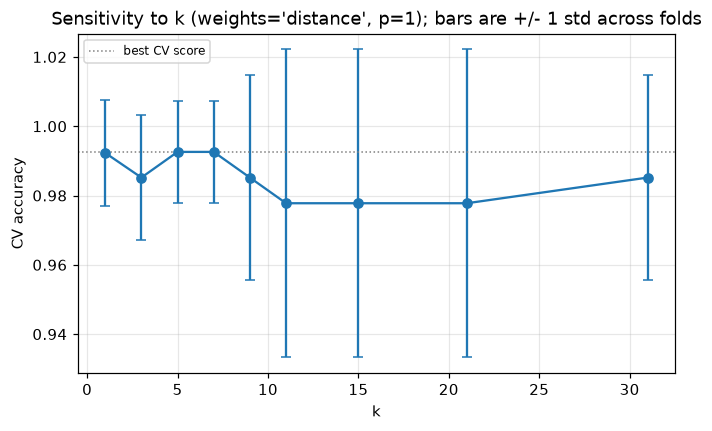

    k    mean CV    std CV   within 1 std of the best?
----------------------------------------------------
    1     0.9923    0.0154                        yes
    3     0.9852    0.0181                        yes
    5     0.9926    0.0148                        yes
    7     0.9926    0.0148                        yes
    9     0.9852    0.0296                        yes
   11     0.9778    0.0444                        yes
   15     0.9778    0.0444                        yes
   21     0.9778    0.0444                        yes
   31     0.9852    0.0296                        yes

9 of the 9 values of k tried are within one standard deviation of
the best, spanning k=1 to k=31.

Take that seriously rather than reporting the winner. On 133 training wines split five
ways, each fold holds ~27 rows, so one wine changing hands moves a fold score by 0.037
- larger than the entire spread of this table. The search has not found the best k; it
has found that k does not matter here, which 

In [17]:
# How sensitive is the answer to k, holding the rest at the winner's settings?
best_w = search.best_params_["knn__weights"]
best_p = search.best_params_["knn__p"]

ks = [1, 3, 5, 7, 9, 11, 15, 21, 31]
mask = ((results["param_knn__weights"] == best_w) & (results["param_knn__p"] == best_p))
sub = results[mask].sort_values("param_knn__n_neighbors")

plt.errorbar(sub["param_knn__n_neighbors"].astype(int), sub["mean_test_score"],
             yerr=sub["std_test_score"], marker="o", capsize=3)
plt.axhline(search.best_score_, color="gray", ls=":", lw=1, label="best CV score")
plt.xlabel("k"); plt.ylabel("CV accuracy")
plt.title(f"Sensitivity to k (weights='{best_w}', p={best_p}); bars are +/- 1 std across folds")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print(f"{'k':>5} {'mean CV':>10} {'std CV':>9}   within 1 std of the best?")
print("-" * 52)
top_score = sub["mean_test_score"].max()
top_std = sub.loc[sub["mean_test_score"].idxmax(), "std_test_score"]
within = []
for _, row in sub.iterrows():
    ok = row["mean_test_score"] >= top_score - top_std
    if ok:
        within.append(int(row["param_knn__n_neighbors"]))
    print(f"{int(row['param_knn__n_neighbors']):>5} {row['mean_test_score']:>10.4f} "
          f"{row['std_test_score']:>9.4f}   {'yes' if ok else 'no':>24}")

print()
print(f"{len(within)} of the {len(sub)} values of k tried are within one standard deviation of")
print(f"the best, spanning k={min(within)} to k={max(within)}.")
print()
print("Take that seriously rather than reporting the winner. On 133 training wines split five")
print("ways, each fold holds ~27 rows, so one wine changing hands moves a fold score by 0.037")
print("- larger than the entire spread of this table. The search has not found the best k; it")
print("has found that k does not matter here, which is a genuine and useful result.")
print()
print("What you should do with that: pick the value you would defend on other grounds - a")
print("middling k for stability - and spend the tuning budget somewhere it can pay off. When")
print("a sweep looks like this, more search is not the answer; more data or better features")
print("are. The one column that IS informative is p: 2.4 showed every tied setting using")
print("Manhattan.")

## 2.5 The test set, once

In [18]:
best = search.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)

print(f"test accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"CV accuracy   : {search.best_score_:.4f}")
print(f"gap           : {accuracy_score(y_test, y_pred) - search.best_score_:+.4f}")

print("\nconfusion matrix (rows = true, cols = predicted):")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=[f"true {c}" for c in wine.target_names],
                   columns=[f"pred {c}" for c in wine.target_names]).to_string())

print("\n" + classification_report(y_test, y_pred, target_names=wine.target_names))

print(f"test set size: {len(y_test)} wines, so one mistake is worth "
      f"{1/len(y_test):.4f} accuracy.")
print("With a test set this small, treat the third decimal place as decoration.")

test accuracy : 0.9778
CV accuracy   : 0.9926
gap           : -0.0148

confusion matrix (rows = true, cols = predicted):
              pred class_0  pred class_1  pred class_2
true class_0            15             0             0
true class_1             0            17             1
true class_2             0             0            12

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

test set size: 45 wines, so one mistake is worth 0.0222 accuracy.
With a test set this small, treat the third decimal place as decoration.


In [19]:
# How does KNN compare against the alternatives, on the same split?
print(f"{'model':<40} {'CV':>9} {'test':>9}")
print("-" * 60)
contenders = [
    ("KNN (tuned)", best),
    ("logistic regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
    ("SVM, RBF kernel", make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE))),
    ("random forest", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                             n_jobs=-1)),
]
for label, model in contenders:
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv).mean()
    model.fit(X_train, y_train)
    print(f"{label:<40} {cv_acc:>9.4f} {model.score(X_test, y_test):>9.4f}")

print()
print("On a clean, small, low-dimensional, well-separated dataset, everything works and the")
print("differences are within noise. That is the normal outcome for wine, and it is a useful")
print("calibration: model choice matters far less than people expect once the preprocessing")
print("is right. The gap that mattered in this notebook was scaling, not architecture.")

model                                           CV      test
------------------------------------------------------------
KNN (tuned)                                 0.9926    0.9778
logistic regression                         0.9775    1.0000
SVM, RBF kernel                             0.9926    0.9778
random forest                               0.9852    1.0000

On a clean, small, low-dimensional, well-separated dataset, everything works and the
differences are within noise. That is the normal outcome for wine, and it is a useful
calibration: model choice matters far less than people expect once the preprocessing
is right. The gap that mattered in this notebook was scaling, not architecture.


## 2.6 Two ways to fix a bad distance

§1.5 gave three defences against irrelevant dimensions. Two of them are one line each in
scikit-learn, and this is a good place to meet them:

- **PCA before KNN** — project onto the directions of highest variance, discarding the rest.
  Cheap, unsupervised, and it decorrelates the features as a side effect.
- **`NeighborhoodComponentsAnalysis`** — *learns* a linear transformation that maximises
  leave-one-out KNN accuracy. This is **metric learning**: instead of accepting Euclidean
  distance, you fit a distance in which your classes actually separate.

Note the ordering constraint: both must come **after** the scaler and **inside** the pipeline.

pipeline                                         CV accuracy
-------------------------------------------------------------
scale -> KNN                                          0.9553
scale -> PCA(5) -> KNN                                0.9775
scale -> PCA(2) -> KNN                                0.9778
scale -> NCA(2) -> KNN                                0.9849


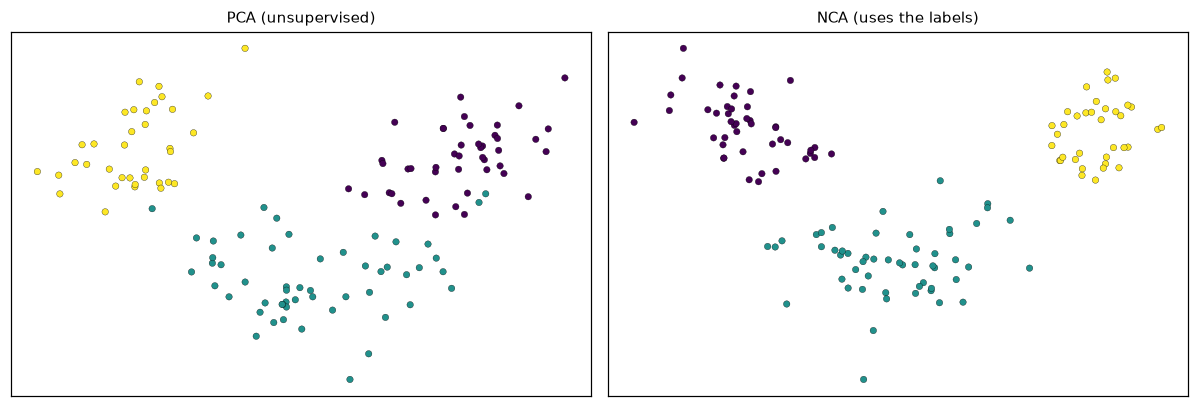

PCA keeps the directions of greatest VARIANCE, which need not be the directions that
separate classes - it never sees the labels. NCA optimises separation directly, which
is why its two dimensions pull the classes into tighter, better-spaced clumps.

The catch is the usual one: NCA uses the training labels, so it MUST be fitted inside
the cross-validation pipeline. Fit it on the full dataset first and you have built a
supervised transform out of your test labels - the leak from NB-00 section 2, in a
form that is easy to miss because 'it is just preprocessing'.


In [20]:
print(f"{'pipeline':<46} {'CV accuracy':>13}")
print("-" * 61)
for label, model in [
    ("scale -> KNN", make_pipeline(StandardScaler(), KNeighborsClassifier())),
    ("scale -> PCA(5) -> KNN",
     make_pipeline(StandardScaler(), PCA(n_components=5, random_state=RANDOM_STATE),
                   KNeighborsClassifier())),
    ("scale -> PCA(2) -> KNN",
     make_pipeline(StandardScaler(), PCA(n_components=2, random_state=RANDOM_STATE),
                   KNeighborsClassifier())),
    ("scale -> NCA(2) -> KNN",
     make_pipeline(StandardScaler(),
                   NeighborhoodComponentsAnalysis(n_components=2, random_state=RANDOM_STATE),
                   KNeighborsClassifier())),
]:
    print(f"{label:<46} {cross_val_score(model, X_train, y_train, cv=cv).mean():>13.4f}")

# Visualise what each projection does to the class structure.
scaled = StandardScaler().fit_transform(X_train)
proj_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled)
proj_nca = NeighborhoodComponentsAnalysis(
    n_components=2, random_state=RANDOM_STATE).fit_transform(scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (title, proj) in zip(axes, [("PCA (unsupervised)", proj_pca),
                                    ("NCA (uses the labels)", proj_nca)]):
    ax.scatter(proj[:, 0], proj[:, 1], c=y_train, cmap="viridis", s=18,
               edgecolor="k", lw=0.2)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

print("PCA keeps the directions of greatest VARIANCE, which need not be the directions that")
print("separate classes - it never sees the labels. NCA optimises separation directly, which")
print("is why its two dimensions pull the classes into tighter, better-spaced clumps.")
print()
print("The catch is the usual one: NCA uses the training labels, so it MUST be fitted inside")
print("the cross-validation pipeline. Fit it on the full dataset first and you have built a")
print("supervised transform out of your test labels - the leak from NB-00 section 2, in a")
print("form that is easy to miss because 'it is just preprocessing'.")

***
# Part 3 - The production objection

Every KNN tutorial sells "no training time!" as an advantage. In production it is the
opposite: KNN moves **all** of the cost from a place where cost is cheap (offline training,
once) to a place where cost is expensive (online inference, every request).

Three consequences, in order of how often they kill a deployment:

1. **Latency grows with your training set.** Every prediction touches every stored point.
2. **The model IS the data.** Deploying it means shipping the training set with it.
3. **You cannot inspect it.** There are no coefficients, no importances, no rules — only
   "these five rows were nearby".

## 3.1 Latency and memory

1000 predictions, 20 features, k=5

  n_train    fit (s)   predict (s)   per query (ms)   stored (MB)
------------------------------------------------------------------
    1,000     0.0032        0.0030            0.003           0.2
    5,000     0.0011        0.0103            0.010           0.8
   20,000     0.0017        0.0278            0.028           3.1
   50,000     0.0030        0.0694            0.069           7.6
  200,000     0.0129        0.2602            0.260          30.5


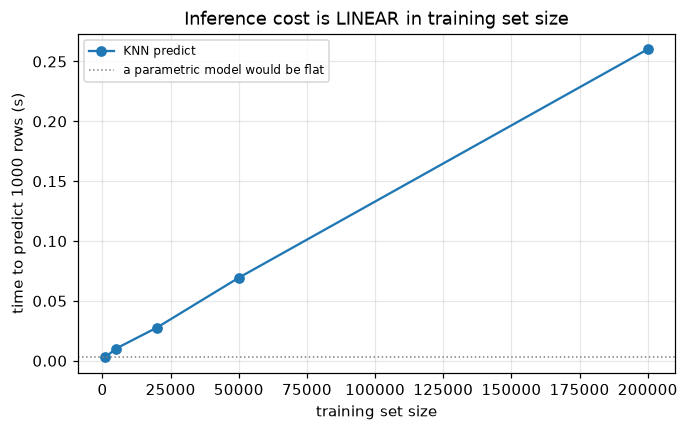


Fit time stays near zero. Predict time and memory grow linearly with the training set.

Now invert that into the sentence a systems reviewer will say to you: 'so every time
we collect more data, the model gets SLOWER and BIGGER?' Yes. For logistic regression,
a random forest or a neural network, more training data costs more offline time and
nothing at inference - the coefficients are the same size either way.


In [21]:
rng = np.random.default_rng(0)
n_features, n_queries = 20, 1000
X_query = rng.normal(size=(n_queries, n_features))

print(f"{n_queries} predictions, {n_features} features, k=5\n")
print(f"{'n_train':>9} {'fit (s)':>10} {'predict (s)':>13} {'per query (ms)':>16} "
      f"{'stored (MB)':>13}")
print("-" * 66)
sizes = [1_000, 5_000, 20_000, 50_000, 200_000]
predict_times = []
for n in sizes:
    X_big = rng.normal(size=(n, n_features))
    y_big = rng.integers(0, 2, n)
    model = KNeighborsClassifier(n_neighbors=5)
    t0 = time.time(); model.fit(X_big, y_big); t_fit = time.time() - t0
    model.predict(X_query[:5])                                   # warm up
    t0 = time.time(); model.predict(X_query); t_pred = time.time() - t0
    predict_times.append(t_pred)
    mb = X_big.nbytes / 1024**2
    print(f"{n:>9,} {t_fit:>10.4f} {t_pred:>13.4f} {t_pred/n_queries*1000:>16.3f} "
          f"{mb:>13.1f}")

plt.plot(sizes, predict_times, marker="o", label="KNN predict")
plt.axhline(predict_times[0], color="gray", ls=":", lw=1,
            label="a parametric model would be flat")
plt.xlabel("training set size"); plt.ylabel(f"time to predict {n_queries} rows (s)")
plt.title("Inference cost is LINEAR in training set size"); plt.legend(fontsize=8)
plt.grid(alpha=0.3); plt.show()

print()
print("Fit time stays near zero. Predict time and memory grow linearly with the training set.")
print()
print("Now invert that into the sentence a systems reviewer will say to you: 'so every time")
print("we collect more data, the model gets SLOWER and BIGGER?' Yes. For logistic regression,")
print("a random forest or a neural network, more training data costs more offline time and")
print("nothing at inference - the coefficients are the same size either way.")

## 3.2 What you can do about it

In roughly the order you should try them:

| Fix | What it costs you |
|---|---|
| **Reduce dimensions** (PCA, feature selection, §2.6) | Some information; the projection must be fitted and shipped |
| **Reduce the data** — subsample, or keep only prototypes / class centroids | Accuracy, if you cut too far |
| **Approximate nearest neighbours** (faiss, hnswlib, annoy, ScaNN) | Exactness — you get *probably* the nearest, orders of magnitude faster |
| **Use a parametric model instead** | KNN's flexibility, which you may not have been using |

The last row is the honest one, and it is the right answer more often than the first three.

In [22]:
# How much data do you actually need? Often far less than you have.
rng = np.random.default_rng(0)
X_pool, y_pool = make_classification(n_samples=20000, n_features=20, n_informative=10,
                                     n_redundant=5, class_sep=1.0,
                                     random_state=RANDOM_STATE)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_pool, y_pool, test_size=4000,
                                              stratify=y_pool, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(Xp_tr)
Xp_tr_s, Xp_te_s = scaler.transform(Xp_tr), scaler.transform(Xp_te)

print(f"{'training rows kept':>19} {'test accuracy':>15} {'predict (s)':>13}")
print("-" * 50)
curve = {}
for frac in [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]:
    n = int(len(Xp_tr_s) * frac)
    idx = rng.choice(len(Xp_tr_s), n, replace=False)
    m = KNeighborsClassifier(n_neighbors=15).fit(Xp_tr_s[idx], yp_tr[idx])
    t0 = time.time(); acc = m.score(Xp_te_s, yp_te); t = time.time() - t0
    curve[frac] = (acc, t)
    print(f"{n:>12,} ({frac:>4.0%}) {acc:>15.4f} {t:>13.4f}")

full_acc, full_t = curve[1.00]
print()
print("Accuracy climbs steeply to about 10% of the data and then crawls, while cost keeps")
print("rising linearly. Read off the trade you are actually being offered:")
for frac in [0.10, 0.25, 0.50]:
    acc, t = curve[frac]
    print(f"  keep {frac:>4.0%} of the rows -> give up {100*(full_acc-acc):>4.1f} accuracy points, "
          f"pay {t/full_t:.0%} of the inference cost")
print()
print("Whether that is a good deal depends entirely on what an error costs you - which is a")
print("product question, not an ML one. The point is that it IS a dial, and most teams never")
print("discover they were allowed to turn it.")
print()
print("Plot this curve BEFORE you argue for a bigger machine - the fix is often to store less.")
print()
print("The reason is section 1.8: once the training set is dense enough that your nearest")
print("neighbour is genuinely similar, adding more points cannot help much. The remaining")
print("error is irreducible noise, and no amount of extra data removes it.")

 training rows kept   test accuracy   predict (s)
--------------------------------------------------
         160 (  1%)          0.7772        0.0058
         800 (  5%)          0.9123        0.0118
       1,600 ( 10%)          0.9175        0.0153
       4,000 ( 25%)          0.9413        0.0404
       8,000 ( 50%)          0.9525        0.0689
      16,000 (100%)          0.9563        0.1271

Accuracy climbs steeply to about 10% of the data and then crawls, while cost keeps
rising linearly. Read off the trade you are actually being offered:
  keep  10% of the rows -> give up  3.9 accuracy points, pay 12% of the inference cost
  keep  25% of the rows -> give up  1.5 accuracy points, pay 32% of the inference cost
  keep  50% of the rows -> give up  0.4 accuracy points, pay 54% of the inference cost

Whether that is a good deal depends entirely on what an error costs you - which is a
product question, not an ML one. The point is that it IS a dial, and most teams never
discover they 

## 3.3 The other production problems

**Missing values.** KNN has no notion of a partial distance — `NaN` propagates and the
prediction is `NaN`. Every missing value must be imputed before the distance is computed.
(There is a pleasing circularity here: `KNNImputer` fills gaps *using* nearest neighbours, and
is a genuinely good imputer — see NB-00 §4.)

**Categorical features.** Euclidean distance on a one-hot encoding is defensible — two
different categories are always $\sqrt{2}$ apart — but a 50-level column becomes 50 features
that collectively swamp your numeric ones. Ordinal encoding is worse: it invents an ordering
and claims category 1 is nearer category 2 than category 9. For genuinely mixed data, prefer
Gower distance or a tree.

**Imbalanced classes.** A majority class that outnumbers the minority 100:1 will usually own
the k nearest neighbours regardless of where the query sits. `weights="distance"` helps a
little; NB-11 covers the real fixes.

**Ties.** With an even k and two classes, votes can tie. sklearn breaks ties by class order,
deterministically but arbitrarily — use odd k for binary problems.

In [23]:
# The imbalance failure, made concrete.
X_imb, y_imb = make_classification(n_samples=5000, n_features=10, n_informative=6,
                                   weights=[0.98, 0.02], class_sep=0.9,
                                   random_state=RANDOM_STATE)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.3,
                                              stratify=y_imb, random_state=RANDOM_STATE)

print(f"minority class is {y_imb.mean():.1%} of the data\n")
print(f"{'model':<34} {'accuracy':>10} {'minority recall':>17}")
print("-" * 64)
for label, model in [
    ("always predict majority", make_pipeline(StandardScaler(),
                                              DummyClassifier(strategy="most_frequent"))),
    ("KNN k=15, uniform", make_pipeline(StandardScaler(),
                                        KNeighborsClassifier(n_neighbors=15))),
    ("KNN k=15, distance", make_pipeline(StandardScaler(),
                                         KNeighborsClassifier(n_neighbors=15,
                                                              weights="distance"))),
    ("KNN k=1", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1))),
]:
    model.fit(Xi_tr, yi_tr)
    pred = model.predict(Xi_te)
    recall = (pred[yi_te == 1] == 1).mean()
    print(f"{label:<34} {accuracy_score(yi_te, pred):>10.4f} {recall:>17.4f}")

print()
print("Read the accuracy column and every KNN looks excellent - all of them score around 97%.")
print("Then notice that predicting the majority class and nothing else ALSO scores 97%, and")
print("that k=1 actually scores WORSE than doing nothing. Read the recall column and the best")
print("of them finds under a third of the minority class.")
print()
print("This is the accuracy trap of NB-00 section 6, sharpened by geometry: a class holding")
print("~97% of the data physically OCCUPIES every neighbourhood, so the vote is decided before")
print("the query is even asked.")
print()
print("Note k=1 has the best recall of the three, for a revealing reason: a single minority")
print("point can win a vote of one, but never a vote of fifteen. It pays for that recall in")
print("accuracy - it is the only model here that loses to the baseline - which is exactly the")
print("trade NB-11 is about. It is not an argument for k=1; it is an argument for choosing")
print("the metric before the model.")

minority class is 2.5% of the data

model                                accuracy   minority recall
----------------------------------------------------------------
always predict majority                0.9747            0.0000
KNN k=15, uniform                      0.9773            0.1053
KNN k=15, distance                     0.9780            0.1316
KNN k=1                                0.9687            0.2895

Read the accuracy column and every KNN looks excellent - all of them score around 97%.
Then notice that predicting the majority class and nothing else ALSO scores 97%, and
that k=1 actually scores WORSE than doing nothing. Read the recall column and the best
of them finds under a third of the minority class.

This is the accuracy trap of NB-00 section 6, sharpened by geometry: a class holding
~97% of the data physically OCCUPIES every neighbourhood, so the vote is decided before
the query is even asked.

Note k=1 has the best recall of the three, for a revealing reason: a

***
# Part 4 - Tough questions

***

### Q1. KNN "trains" instantly. So why is it considered an expensive model?

<details><summary>Answer</summary>

Because cost was **moved, not removed** — from a cheap place to an expensive one.

|  | Parametric model (logistic regression, forest, network) | KNN |
|---|---|---|
| Training | Minutes to hours, **once, offline** | ~0 s |
| Prediction | Constant time, tiny | $O(nd)$ — touches every stored point |
| Model size | Fixed by parameter count | **The entire training set** |
| More data | Slower training, same inference | **Slower inference, bigger model** |

Training cost is paid once, offline, where nobody is waiting. Inference cost is paid on every
request, in the latency budget, forever.

§3.1 measures it: predict time and memory grow **linearly** with the training set, while a
parametric model's stay flat. The sentence that ends deployments is *"so every time we collect
more data, the service gets slower?"*

The subtler cost is operational: shipping the model means shipping the **training data** — into
your production environment, your container image, your memory budget, and possibly across a
privacy boundary you did not intend to cross.

</details>

***

### Q2. Why does KNN need feature scaling when a decision tree does not?

<details><summary>Answer</summary>

Because they consume features in fundamentally different ways.

**KNN aggregates across features.** Euclidean distance sums $(x_j - z_j)^2$ over all $j$ in
each feature's own units. A feature ranging over thousands contributes terms in the millions;
a feature ranging over [0, 1] contributes at most 1. The second feature is not down-weighted —
it is **invisible**. §1.2 shows wine going from 0.68 to 0.97 accuracy on scaling alone, and
measures one feature (proline) holding 99.8% of the unscaled variance — the model was reading
one column and ignoring twelve.

**A tree compares one feature at a time to a threshold.** `proline > 755` is unaffected by
whether proline is measured in mg/L or g/L — the threshold rescales with it. Any monotone
transformation of a single feature leaves the tree unchanged (NB-03 §1.6).

**The general rule:** any model that *combines* features into one number needs comparable
scales. That covers KNN, k-means, SVMs with RBF kernels, PCA, and any regularised linear
model — regularisation penalises $\sum w_j^2$, which mixes units the same way.

The nastiest part is that KNN does not fail loudly. The unscaled wine model still beats the
baseline by a wide margin. It just quietly became a one-feature model.

</details>

***

### Q3. Your KNN gets 100% training accuracy with k=1. Is that good?

<details><summary>Answer</summary>

It is **meaningless** — it is arithmetically guaranteed and carries no information.

With k=1, the nearest neighbour of any training point is **itself**, at distance zero. So the
model returns that point's own label, every time, on every dataset, however noisy. §1.3
verifies the training accuracy is exactly 1.0.

This is the cleanest example in the series of why training scores cannot measure fit. Related
traps that are less obvious:

- **Duplicate rows across the split.** If the same row appears in train and test, the test
  point's nearest neighbour is at distance zero and its label is exact. Deduplicate before
  splitting.
- **`cross_val_score` on a k=1 model looks fine** — CV holds points out properly, so it does
  give an honest number. The trap is specifically *training* accuracy.
- **k=1 is not always wrong.** Cover & Hart (§1.8) says 1-NN is asymptotically within 2× of
  optimal, and on very clean, low-noise data it can be genuinely competitive. Choose it from
  cross-validation, never from a training score.

</details>

***

### Q4. What actually goes wrong in high dimensions? "The curse of dimensionality" is not an answer.

<details><summary>Answer</summary>

The mechanism is **distance concentration**, and §1.5 measures it.

For uniformly distributed points, the ratio
$$\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0 \quad \text{as } d \to \infty$$

Measured with 500 random points: at $d=1$ the farthest point is over **600×** further away
than the nearest; at $d=1000$ it is **10%** further. The coefficient of variation of the
distances falls from 0.61 to 0.017.

**Why:** distance is a sum of $d$ per-feature terms. By the law of large numbers that sum
concentrates around its expectation as $d$ grows, and the *relative* spread shrinks like
$1/\sqrt{d}$. Meanwhile the volume of the space grows exponentially, so any fixed sample size
becomes vanishingly sparse.

**What breaks:** KNN's entire premise is that the nearest points are meaningfully more similar
than the far ones. When all distances are equal to within noise, "nearest neighbour" is
effectively a random draw.

**The practical version** — §1.5's second experiment — is worse and more common than the pure
geometry: adding *irrelevant* features to a solvable problem destroys KNN while a random
forest barely notices, because every noise feature adds its own term to the distance while a
tree simply never splits on it.

**Defences:** feature selection · dimensionality reduction (PCA, §2.6) · metric learning (NCA,
§2.6) · Manhattan distance, which §1.5 measures concentrating more slowly than Euclidean ·
or accept that a model which can *ignore* features is the better tool.

None of them *fixes* the problem — they buy you dimensions. Only the last one changes the
kind of model you are running.

**The caveat that matters:** this analysis assumes points fill the space uniformly. Real
high-dimensional data usually lies on a much lower-dimensional **manifold** — images,
embeddings, text vectors — and its *intrinsic* dimension may be tiny. That is exactly why
nearest-neighbour search on 768-dimensional embeddings works in practice: the effective
dimension is far below 768.

</details>

***

### Q5. Should you use `weights="uniform"` or `weights="distance"`?

<details><summary>Answer</summary>

`"distance"` is the better **default**, but the reason is not "it is more accurate".

Under uniform weighting all k neighbours vote equally, including the one that is far away and
barely relevant. Under distance weighting each votes with weight $1/d$.

§1.4 shows where this bites. At a sensible k the two are indistinguishable. At k=101 — more
than half the wine dataset — uniform voting **collapses** (0.7586) while distance weighting
holds (0.9663), because the far-away points get near-zero weight and are effectively ignored.

So distance weighting is mainly **robustness to a badly chosen k**: it costs nothing when k is
right and saves you when k is too large. It also smooths KNN regression's staircase (§1.7).

Two things to know:

- **It makes the effective k data-dependent.** In a dense region many neighbours contribute; in
  a sparse region one nearby point dominates. That is usually what you want, but it means k no
  longer controls smoothing as directly.
- **It can overfit in noisy data.** A mislabelled point sitting right next to a query gets an
  enormous weight ($1/d \to \infty$ as $d \to 0$). Uniform weighting caps any single point's
  influence at $1/k$; distance weighting does not.

Tune it. It is one binary flag and it interacts with k, which is exactly why §2.4 searches
them together.

</details>

***

### Q6. When would you pick KNN over a gradient-boosted tree?

<details><summary>Answer</summary>

Honestly: **rarely, for straight tabular prediction.** NB-05 wins that comparison almost
always. But there are real cases:

1. **You need the neighbours themselves, not just the prediction.** Recommenders ("users like
   you"), deduplication, record linkage, near-duplicate detection, retrieval for RAG. Here the
   neighbour list *is* the product, and a boosted tree cannot give you one.
2. **Instant updates matter more than inference speed.** Adding a row is an append. No
   retraining, no redeployment. For a catalogue that changes hourly, that is a genuine
   operational advantage.
3. **Few features, lots of data, weird boundary.** KNN's non-parametric boundary can capture
   shapes no parametric model will find, and low $d$ keeps the curse at bay.
4. **You have a good learned embedding already.** Modern semantic search *is* KNN — on top of a
   neural encoder that solved the distance problem for you. The representation does the
   learning; KNN does the lookup.
5. **As a baseline.** Ten seconds of work, and a boosted model that cannot beat KNN is telling
   you something about your features.
6. **Explaining a prediction to a non-technical stakeholder.** "These three past cases were the
   most similar, and all three were fraud" is a case-based justification people accept — and it
   is far more concrete than a SHAP plot (NB-12).

**Pick the tree instead when:** you have many features, mixed types, missing values, or
imbalanced classes; when you need calibrated probabilities; or when inference latency is
budgeted.

</details>

***

### Q7. KNN gives probabilities via `predict_proba`. Should you trust them?

<details><summary>Answer</summary>

**Not without checking, and especially not at small k.**

`predict_proba` returns the fraction of the k neighbours in each class (weighted by $1/d$ if
distance weighting is on). Consequences:

- **The output is quantised.** With k=5, the only possible probabilities are 0, 0.2, 0.4, 0.6,
  0.8, 1.0. "73% likely" is unrepresentable.
- **k=1 gives only 0.0 and 1.0** — maximally overconfident, always.
- **Small k means high variance.** With k=5, a single neighbour flipping moves the estimate by
  0.2.

The counterweight is that KNN's probabilities are **not systematically distorted** the way an
SVM's decision function is — they are honest local frequency estimates, just coarse ones. With
large k in a dense region they can be quite well calibrated.

**In practice:** use a larger k if you need probabilities (k=50 gives 2-point resolution), use
distance weighting to de-quantise the output, and check a **calibration curve** and Brier score
rather than assuming (NB-00 §7, NB-02 Part 3). If it is miscalibrated, wrap in
`CalibratedClassifierCV` — but note that fitting a calibrator on top of a KNN multiplies an
already-expensive inference path.

</details>

***

### Q8. Does using a KD-tree make KNN fast?

<details><summary>Answer</summary>

**In low dimensions, yes. Above roughly 15–20 features, it makes it slower.**

KD-trees and ball-trees work by **pruning**: "nothing in this region can be closer than what I
already have, so skip it". Pruning requires that regions be reliably far away — which is
exactly what distance concentration (Q4) destroys. In high dimensions nearly every region
*could* contain a closer point, so the tree visits almost every node **and** pays the traversal
overhead on top.

§1.6 measures it, 5,000 stored points, 1,000 queries:

| dimensions | brute force | KD-tree |
|---|---|---|
| 2 | slower | **faster** |
| 5–20 | **faster** | slower |
| 100 | **much faster** | over an order of magnitude slower |

(The exact factors depend on your machine; the crossover between d=2 and d=5 does not.)

Brute force is also heavily vectorised — it is a single large matrix operation hitting BLAS,
with no branching and perfect cache behaviour. That is hard to beat.

**What to do:** leave `algorithm="auto"`; sklearn's heuristic already switches to brute force
in high dimensions. If you genuinely need fast neighbour search on high-dimensional data, the
answer is **approximate** nearest neighbours — HNSW graphs (`hnswlib`), inverted file indexes
and product quantisation (`faiss`), or random projection forests (`annoy`). They trade
exactness for orders of magnitude, and for most applications you cannot tell the difference.

</details>

***

### Q9. Why can't KNN regression extrapolate?

<details><summary>Answer</summary>

Because every prediction is an **average of training targets**, and an average of numbers in
$[y_{\min}, y_{\max}]$ is itself in $[y_{\min}, y_{\max}]$. No input can produce an output
outside the observed target range — ever.

§1.7 shows it: trained on $y = 2x+3$ for $x \in [0, 10]$, the predictions at $x=15$ and $x=25$
are the **same number** — the average of the five rightmost training points, a little under 23
— against truths of 33 and 53. Beyond the data the k nearest neighbours never change, so the
answer is their average, **forever**, as a flat line.

**This is exactly the regression-tree limitation from NB-03**, for the same underlying reason —
both are local-averaging methods. It is a defining property of non-parametric local methods,
not a bug.

Linear regression extrapolates because it fits a *functional form* and evaluates it anywhere.
Whether that extrapolation is *correct* is a separate question — it commits confidently to a
straight line, which can be far more wrong than being flat.

**In practice:** if your production inputs can fall outside the training range (prices,
volumes, dates, anything trending), a local-averaging model will silently return its edge value
with no warning. Monitor for out-of-range inputs explicitly (NB-00 Part 9); this is a
distribution-shift alarm you can implement in one line.

</details>

***

### Q10. What does Cover & Hart's $R_{1NN} \le 2R^*$ result actually tell you?

<details><summary>Answer</summary>

That **1-NN is asymptotically within a factor of two of the best classifier that could
possibly exist** — where $R^*$ is the Bayes error, the irreducible error of a classifier that
knows the true conditional distribution exactly.

The intuition: with enough data, your nearest neighbour is so close that it is effectively a
second independent draw from the same conditional distribution $P(y \mid x)$. 1-NN is then
"asking one other person who was in the same situation", and it errs only when the two draws
disagree — which for a two-class problem is $2p(1-p) \le 2\min(p, 1-p)$.

§1.8 verifies it numerically: with a known Bayes error of 0.1587, 1-NN settles at ~0.22 — inside
the bound, and closer to $R^*$ than to $2R^*$, which is typical. k=15 lands near 0.17, close to
$R^*$ itself, as theory predicts for $k \to \infty$ with $k/n \to 0$.

**What it is good for:** it tells you KNN's error is dominated by *irreducible noise*, not by
model mis-specification. So when KNN is far worse than the alternatives, the cause is almost
never "KNN is too simple" — it is your **distance** (unscaled features) or your **dimensions**
(irrelevant columns).

**What it is not good for:** the result is asymptotic. Reaching that regime requires the data
to be dense enough that your nearest neighbour is genuinely close — and the sample size for
that grows **exponentially** in dimension. The theorem and the curse of dimensionality are the
same statement viewed from two sides.

</details>

***

### Q11. How would you use KNN on a dataset with categorical features and missing values?

<details><summary>Answer</summary>

Carefully, and only after asking whether a tree would be the better tool — this is the data
shape KNN handles worst.

**Missing values.** There is no partial distance: `NaN` propagates and predictions become
`NaN`. Every gap must be filled first. Options: `SimpleImputer` (fast, blunt), or `KNNImputer`
— which imputes using nearest neighbours computed on the non-missing features, and is genuinely
good. Note the recursion, and note that `KNNImputer` inherits every problem in this notebook:
it needs scaling too, and it degrades in high dimensions.

**Categoricals.**

- **One-hot + Euclidean** is defensible: two distinct categories are always $\sqrt{2}$ apart,
  which is a sensible "different is different". But a 50-level column becomes 50 features that
  collectively dominate your handful of numeric ones — you have silently re-created the scaling
  trap through cardinality.
- **Ordinal encoding is wrong** unless the categories are genuinely ordered. It asserts that
  category 1 is nearer to 2 than to 9, which for `city_id` is nonsense.
- **Gower distance** handles mixed types properly — Manhattan for numeric, matching for
  categorical, averaged with weights. Not in sklearn; `gower` on PyPI, or pass a custom
  callable to `metric=`.
- **Target/frequency encoding** maps a category to a meaningful number, which distance can then
  use — but it is supervised, so it must be fitted inside the CV pipeline or it leaks.

**The honest answer in an interview:** mixed types with missing values is precisely where
gradient boosting wins (NB-05) — it handles both natively, needs no scaling, and ignores
irrelevant columns. Recognising that KNN is the wrong tool is the better answer than the
cleverest encoding scheme.

</details>

***

### Q12. Your KNN scores 0.95 in cross-validation and 0.70 in production. Give five explanations, ranked.

<details><summary>Answer</summary>

1. **A scaling mismatch.** The production pipeline computes different means and standard
   deviations than training did — or skips scaling entirely, or was re-fitted on production
   data. Because distance is scale-sensitive (§1.2), this is catastrophic and invisible: no
   error, just worse answers. Ship the *fitted* scaler as part of the pipeline artifact, and
   assert on its parameters.
2. **Preprocessing leakage during evaluation.** If a scaler, imputer, PCA or NCA was fitted
   before the split rather than inside the pipeline (§2.3, §2.6), the CV score was optimistic
   from the start. NCA is the sneakiest — it uses labels, so fitting it outside CV leaks the
   test labels into the geometry.
3. **Duplicate or near-duplicate rows across the split.** KNN is uniquely vulnerable: a
   duplicate in the training set is at distance zero from its test twin, so the test label is
   exact. Common with repeated events, resampled sensor data, or multiple rows per customer —
   deduplicate, and use `GroupKFold` when rows share an entity.
4. **Distribution shift into a region with no neighbours.** Production inputs that fall outside
   the training cloud get whatever happens to be nearest, however far away — and for regression
   the prediction is pinned to the edge value (Q9). Log the *distance to the nearest neighbour*
   at inference: a rising distribution of that is an early warning nothing else gives you.
5. **A silently changed feature set.** A column reordered, renamed, dropped, or arriving in
   different units. KNN cannot detect this — every feature just contributes to the sum. A tree
   would at least keep working on the columns it recognises.

**The KNN-specific diagnostic that catches most of these:** log the mean distance to the k
nearest neighbours in production and compare it against the training distribution. If
production queries are systematically further from your stored data than training queries were,
every explanation above becomes visible in a single chart.

</details>

***

## Coding challenges

### Challenge 1 — find where the curse actually bites *your* problem

§1.5 uses uniform random points, which is the worst case. Real data is friendlier. Measure it:

1. Take `load_breast_cancer` (30 features). Compute the distance-concentration ratio
   $(d_{\max}-d_{\min})/d_{\min}$ on the **real** data, then on **shuffled** data (shuffle each
   column independently — this destroys structure while keeping every marginal distribution).
2. The real data should concentrate *less*. Explain why in terms of intrinsic dimension.
3. Add 10, 50, 200 columns of Gaussian noise. Plot the ratio and KNN's CV accuracy against the
   number of added columns on the same axes. Where does accuracy start falling — at the same
   point the ratio collapses, or before?
4. Now repeat with `PCA(n_components=10)` in front of the KNN. How much of the damage does it
   undo, and why can it not undo all of it?

***

### Challenge 2 — build a condensed KNN

Prototype selection: keep only the training points that matter.

1. Implement **Hart's Condensed Nearest Neighbour**: start with one point per class; sweep the
   training set repeatedly, adding any point the current subset misclassifies; stop when a full
   sweep adds nothing.
2. On `make_classification(n_samples=5000, n_features=10)`, report the retained fraction, the
   test accuracy, and the prediction time — against full KNN.
3. Plot the retained points. Where do they sit relative to the decision boundary? Compare that
   picture with the SVM support vectors from NB-06 §1.2. Two entirely different algorithms
   arrive at the same insight — why?
4. Which points does condensing *fail* on? Feed it 5% label noise and see what it retains.

***

### Challenge 3 — the recommender KNN

Use KNN the way industry actually uses it: to retrieve, not to classify.

1. Load MovieLens 100k (`https://files.grouplens.org/datasets/movielens/ml-latest-small.zip`)
   and build a user × item rating matrix.
2. Use `NearestNeighbors(metric="cosine")` to find each user's 20 most similar users. **Why
   cosine and not Euclidean?** (Hint: what does the magnitude of a user's rating vector
   encode?)
3. Predict a held-out rating as the similarity-weighted average of those neighbours' ratings.
   Report RMSE against two baselines: the global mean, and the item's mean.
4. **Cold start:** what does your system do for a user with two ratings? For a brand-new
   movie? Neither has meaningful neighbours — decide what to return and defend it.
5. Time a single recommendation as the user count grows. At what point would you need
   approximate nearest neighbours (Q8)?

***
# Part 5 - Five datasets to practise on

Chosen so that each one breaks KNN in a different way.

| # | Dataset | Rows × cols | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Iris** | 150 × 4 | The one case where KNN is genuinely excellent | ★☆☆☆☆ |
| 2 | **Breast cancer** | 569 × 30 | Scaling, tuning, and probability quality | ★★☆☆☆ |
| 3 | **Digits** | 1,797 × 64 | KNN as a strong image baseline; PCA in front | ★★★☆☆ |
| 4 | **Adult / census** | 48,842 × 14 | Mixed types, missing values, **and 48k rows at inference** | ★★★★☆ |
| 5 | **Fashion-MNIST** | 70,000 × 784 | Where brute force is the only option and cost becomes real | ★★★★★ |

In [24]:
from sklearn.datasets import load_iris, load_digits, fetch_openml

CATALOGUE = [
    ("Iris", lambda: load_iris(as_frame=True)),
    ("Breast cancer", lambda: load_breast_cancer(as_frame=True)),
    ("Digits", lambda: load_digits(as_frame=True)),
]

print(f"{'dataset':<18} {'rows':>7} {'cols':>6} {'classes':>8}   bundled with sklearn")
print("-" * 66)
with warnings.catch_warnings():
    # load_digits reshapes an array in place, which NumPy 2.5 deprecates. The warning
    # comes from inside scikit-learn 1.9, not from anything here, and there is nothing
    # to fix on our side - so it is suppressed narrowly, around this loop only.
    warnings.filterwarnings("ignore", category=DeprecationWarning,
                            message=".*shape on a NumPy array.*")
    for label, loader in CATALOGUE:
        b = loader()
        print(f"{label:<18} {b.data.shape[0]:>7} {b.data.shape[1]:>6} "
              f"{len(np.unique(b.target)):>8}   yes")

print()
print("Adult (~5 MB) and Fashion-MNIST (~30 MB) download from OpenML on first use and cache")
print("afterwards - loaders are in the briefs below rather than fetched here.")
print()

# A quick illustration of why Iris is on the list.
iris = load_iris()
print(f"KNN on iris, 4 features, well separated: "
      f"{cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), iris.data, iris.target, cv=cv).mean():.4f}")
print("Low dimension, clean clusters, balanced classes - KNN's ideal conditions, and it is")
print("genuinely hard to beat here. Start where the model works, then break it.")

dataset               rows   cols  classes   bundled with sklearn
------------------------------------------------------------------
Iris                   150      4        3   yes
Breast cancer          569     30        2   yes
Digits                1797     64       10   yes

Adult (~5 MB) and Fashion-MNIST (~30 MB) download from OpenML on first use and cache
afterwards - loaders are in the briefs below rather than fetched here.

KNN on iris, 4 features, well separated: 0.9733
Low dimension, clean clusters, balanced classes - KNN's ideal conditions, and it is
genuinely hard to beat here. Start where the model works, then break it.


### 1. Iris — where KNN is genuinely excellent

```python
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
```

Four features, three well-separated species. KNN's home ground.

1. Sweep k from 1 to 50. Plot CV accuracy with error bars. How wide is the plateau, and where
   does large k finally hurt?
2. Fit on only `petal length` and `petal width` and plot the decision boundary for k = 1, 5,
   25. Watch the islands disappear.
3. Compare `weights="uniform"` and `"distance"` across that same k sweep. At what k do they
   separate, and does it match §1.4's explanation?
4. Iris is small enough to do leave-one-out CV (`cv=len(X)`). Compare LOO against 5-fold —
   which is more optimistic, and why does that make sense for a local method?

***

### 2. Breast cancer — scaling, tuning, probabilities

```python
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
```

30 features on very different scales, and a task where probabilities genuinely matter.

1. Quantify the scaling gap, as §1.2 did for wine. Is it larger or smaller, and can you
   predict the answer from the feature ranges before running it?
2. Grid-search k × weights × p. Then check: how much better is the winner than a plain
   `KNeighborsClassifier()` at defaults? Was the search worth it?
3. Plot a **calibration curve** for k = 1, 5, 50 (NB-00 §7). Watch the quantisation in Q7
   become visible, and confirm that large k gives finer resolution.
4. This is a screening task: false negatives cost far more than false positives. Tune the
   decision threshold on the *predicted probabilities* rather than accepting 0.5 (NB-02 Part 3).
5. Compare against logistic regression on **Brier score**, not accuracy. Which would you ship?

***

### 3. Digits — KNN as a serious image baseline

```python
from sklearn.datasets import load_digits
X, y = load_digits(return_X_y=True)
```

64 pixel features. KNN on raw pixels is a genuinely strong baseline here, which surprises
people who expect it to be useless on images.

1. Fit plain KNN. Compare against logistic regression and a random forest. Where does it land?
2. **Do the pixels need scaling?** They are all on the same 0–16 scale. Try it — does
   `StandardScaler` help, hurt, or do nothing, and why is that a different answer than for wine?
3. Sweep `PCA(n_components=)` from 5 to 64 in front of the KNN. Plot accuracy **and** predict
   time. Find the point where reducing dimensions improves *both* — and explain it with §1.5.
4. Which digits get confused? Pull up the actual nearest neighbours for a few misclassified
   images and look at them. This is a diagnostic no other model gives you for free.
5. Now shift every image one pixel right and re-test. Accuracy will collapse. What does that
   tell you about Euclidean distance on raw pixels — and what do CNNs do about it?

***

### 4. Adult / census — the wrong shape for KNN, on purpose

```python
bunch = fetch_openml(name="adult", version=2, as_frame=True)
```

48k rows, 8 categorical columns, missing values. Every weakness in Q11 at once.

1. Build the pipeline: impute → one-hot → **scale** → KNN. Count your columns after one-hot
   encoding. How many of them came from a single high-cardinality feature?
2. Time one prediction batch of 1,000 rows with all 48k rows stored. Now compute what that
   costs at 100 requests per second.
3. Compare against `HistGradientBoostingClassifier` with native categorical support on both
   accuracy and total wall-clock. Report the comparison honestly, including preprocessing.
4. Try `KNNImputer` instead of `SimpleImputer`. Does the better imputation pay for its cost?
5. Subsample the training set to 10%, 25%, 50%. Plot accuracy against stored rows (§3.2). How
   much data could you throw away for free?

***

### 5. Fashion-MNIST — where the cost becomes the whole problem

```python
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)
```

70,000 images × 784 pixels. Warning: a full KNN fit-and-predict here is slow — that is the
lesson.

1. Start with a 10,000-row subsample. Time a 1,000-row prediction. Extrapolate to the full
   70k, then verify your estimate on 20k. Was the scaling linear, as §3.1 says?
2. Compare `algorithm="brute"`, `"kd_tree"` and `"ball_tree"` at 784 dimensions. Confirm §1.6:
   the trees should lose badly. Explain why to someone who has not read Q8.
3. PCA to 50 dimensions, then KNN. Measure accuracy **and** time. This should be both faster
   *and* at least as accurate — the single most useful trick in this notebook.
4. Install `hnswlib` or `faiss-cpu` and build an approximate index. Measure the accuracy you
   lose against the speed you gain. At what recall does the accuracy drop become visible?
5. Finish the argument: at 70k stored images, what would you actually deploy, and what would
   you have to give up? There is no free answer here — that is the point.

***
# Part 6 - Reading the literature

KNN's literature is unusual: the foundational papers are **short**, the maths is elementary,
and the two most important results are both immediately intuitive once stated. This is the
easiest entry point into reading ML papers in the whole series.

## Start here

**1. [Nearest Neighbor Pattern Classification](https://isl.stanford.edu/~cover/papers/transIT/0021cove.pdf)** —
Thomas Cover & Peter Hart, *IEEE Transactions on Information Theory* 13(1):21-27, 1967.
**Free.**
> **Read this one.** Seven pages, and it proves the $R^* \le R_{1NN} \le 2R^*$ bound of §1.8 —
> that a rule which does no learning at all is asymptotically within a factor of two of optimal.
> The proof needs nothing beyond conditional probability. It is one of the most quotable results
> in machine learning and one of the few classic papers a beginner can genuinely read end to end.

**2. [When Is "Nearest Neighbor" Meaningful?](https://link.springer.com/chapter/10.1007/3-540-49257-7_15)** —
Kevin Beyer, Jonathan Goldstein, Raghu Ramakrishnan & Uri Shaft, ICDT 1999.
> **The curse of dimensionality, made precise.** This is the paper behind §1.5: under broad
> conditions, as dimension grows the distance to the nearest neighbour converges to the distance
> to the farthest, so the *concept* of a nearest neighbour becomes unstable. Read the abstract
> and Section 1 even if you skip the proofs — it reframes "high dimensions are bad" into a
> specific, testable statement.

**3. [On the Surprising Behavior of Distance Metrics in High Dimensional Space](https://bib.dbvis.de/uploadedFiles/155.pdf)** —
Charu Aggarwal, Alexander Hinneburg & Daniel Keim, ICDT 2001. **Free.**
> The follow-up, and immediately practical: it shows that **Manhattan ($L_1$) concentrates more
> slowly than Euclidean ($L_2$)**, and that fractional norms ($L_{0.5}$) are better still. This
> is the theory behind the `p=1` option in §1.4 and the reason it is worth including in a grid
> search.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.1 — the nearest-neighbour rule itself | **Fix & Hodges**, *Discriminatory Analysis: Nonparametric Discrimination*, USAF report, **1951** — the original, reprinted in *International Statistical Review* 57(3), 1989 | 🔍 |
| 1.3 — k as a bias-variance dial | Hastie, Tibshirani & Friedman, *ESL* §2.3 and §13.3 — [free PDF](https://hastie.su.domains/ElemStatLearn/) | ✅ |
| 1.4 — distance metrics in high dimensions | **Aggarwal, Hinneburg & Keim**, ICDT **2001** — [pdf](https://bib.dbvis.de/uploadedFiles/155.pdf) | ✅ |
| 1.5 — **distance concentration** | **Beyer, Goldstein, Ramakrishnan & Shaft**, ICDT **1999** | 🔍 |
| 1.6 — KD-trees | **Bentley**, *Multidimensional Binary Search Trees Used for Associative Searching*, CACM 18(9), **1975** | 🔍 |
| 1.6 — ball-trees | **Omohundro**, *Five Balltree Construction Algorithms*, ICSI TR-89-063, **1989** — [pdf](https://www.icsi.berkeley.edu/icsi/node/2274) | ✅ |
| 1.8 — **the $2R^*$ bound** | **Cover & Hart**, IEEE Trans. Inf. Theory **1967** — [pdf](https://isl.stanford.edu/~cover/papers/transIT/0021cove.pdf) | ✅ |
| 2.6 — metric learning (NCA) | **Goldberger, Roweis, Hinton & Salakhutdinov**, *Neighbourhood Components Analysis*, NeurIPS **2004** — [pdf](https://www.cs.toronto.edu/~hinton/absps/nca.pdf) | ✅ |
| 2.6 — large-margin metric learning | **Weinberger & Saul**, *Distance Metric Learning for Large Margin Nearest Neighbor Classification*, JMLR 10, **2009** — [pdf](https://www.jmlr.org/papers/volume10/weinberger09a/weinberger09a.pdf) | ✅ |
| 3.2 — approximate nearest neighbours (HNSW) | **Malkov & Yashunin**, *Efficient and Robust ANN Search Using Hierarchical Navigable Small World Graphs*, IEEE TPAMI **2020** — [arXiv](https://arxiv.org/abs/1603.09320) | ✅ |
| 3.2 — billion-scale ANN in practice | **Johnson, Douze & Jégou**, *Billion-Scale Similarity Search with GPUs* (**FAISS**), IEEE Big Data **2019** — [arXiv](https://arxiv.org/abs/1702.08734) | ✅ |
| 3.3, Q11 — KNN imputation | **Troyanskaya et al.**, *Missing Value Estimation Methods for DNA Microarrays*, Bioinformatics 17(6), **2001** | 🔍 |
| Challenge 2 — condensed NN | **Hart**, *The Condensed Nearest Neighbor Rule*, IEEE Trans. Inf. Theory 14(3), **1968** | 🔍 |
| Q6 — KNN as retrieval, in modern systems | **Karpukhin et al.**, *Dense Passage Retrieval for Open-Domain QA*, EMNLP **2020** — [arXiv](https://arxiv.org/abs/2004.04906) | ✅ |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**Cover & Hart (1967).** Seven pages, elementary probability, and a result you will quote for
the rest of your career. If you have been putting off reading a research paper because they
look impenetrable, this is the one to start with — then read **Beyer et al. (1999)** for the
reason it does not save you in high dimensions.

### The modern connection

KNN did not fade away — it moved. Every vector database (Pinecone, Weaviate, Milvus, pgvector)
and every retrieval-augmented generation system is running approximate KNN over neural
embeddings. **Malkov & Yashunin (2020)** is the algorithm most of them actually use, and
**Karpukhin et al. (2020)** is the paper that made "embed everything, then find the nearest
neighbours" the standard architecture for retrieval.

The change is not the lookup — it is the **representation**. A learned encoder produces a space
where Euclidean or cosine distance means something, which is exactly the problem §1.5 says KNN
cannot solve on its own. Neural networks solved KNN's distance problem, and KNN is doing very
well out of the arrangement.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| Mediocre accuracy for no visible reason | **Unscaled features** (§1.2) — by far the most common | `StandardScaler` inside the Pipeline |
| Training accuracy exactly 1.0 | k=1: every point is its own neighbour (§1.3) | Ignore training scores entirely; use CV |
| CV great, production poor | Scaler mismatch, leakage, or duplicate rows across the split (Q12) | Ship the fitted pipeline; deduplicate before splitting |
| Accuracy falls as you add features | Curse of dimensionality (§1.5) | Feature selection, PCA, or NCA (§2.6) |
| Predictions are `NaN` | `NaN` propagates through the distance | Impute first — `SimpleImputer` or `KNNImputer` |
| Regression predictions flat at the edges | KNN cannot extrapolate (§1.7) | Expected behaviour; monitor for out-of-range inputs |
| Probabilities are only 0, 0.2, 0.4… | Quantisation: they are vote fractions (Q7) | Larger k, `weights="distance"`, or calibrate |
| Minority class rarely predicted | The majority owns the neighbourhood (§3.3) | `weights="distance"`, resampling — see NB-11 |
| Inference too slow | $O(nd)$ per query (§3.1) | Reduce d, reduce n, or use ANN (faiss / hnswlib) |
| `kd_tree` slower than brute force | Trees stop pruning above ~15-20 dimensions (§1.6) | `algorithm="auto"` or `"brute"` |
| `MemoryError` on predict | The distance matrix is n_queries × n_train | Predict in batches; reduce stored data |
| Ties in binary classification | Even k | Use odd k |
| One-hot column swamps the numerics | 50 dummies vs 5 numeric features (Q11) | Gower distance, target encoding, or use a tree |

## Checklist for shipping a KNN

Everything in the Foundations checklist, plus:

- [ ] Are features **scaled**, with the scaler **inside** the Pipeline and shipped with it?
- [ ] Were k, `weights` and the metric tuned **together** by cross-validation — never by
      training score?
- [ ] Have duplicate and near-duplicate rows been removed **before** splitting?
- [ ] Do I know my inference latency at the training-set size I expect in **six months**, not
      today?
- [ ] How many dimensions am I computing distances in, and have I tried PCA or feature
      selection to cut it?
- [ ] For regression: can production inputs fall outside the training range, and am I alerting
      on it?
- [ ] If I use probabilities, is k large enough that they have usable resolution — and have I
      checked a calibration curve?
- [ ] Am I logging the **distance to the nearest neighbour** at inference, as a
      distribution-shift alarm?
- [ ] Have I compared against a boosted tree, so I know what the memory cost is buying me?

## Where to go next

| Notebook | Why it follows |
|---|---|
| `naive_bayes_zero_to_hero.ipynb` | The other "embarrassingly simple model that works anyway" — and the opposite design: strong assumptions, tiny model, instant inference. |
| `pca_zero_to_hero.ipynb` | §2.6 used PCA to rescue a distance and only showed you the outcome. This is what it actually does. |
| `kmeans_zero_to_hero.ipynb` | The unsupervised sibling. Same Euclidean distance, same scaling requirement, same curse — applied to finding structure instead of labels. |
| `imbalanced_classification_zero_to_hero.ipynb` | §3.3 showed KNN failing on a 98:2 split and stopped there. This is the fix. |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.